# Presentación base de datos: UTD Multimodal Human Action Dataset


## Sensores usados

  ### Cámara kinect


 La cámara kinect puede capturar imagenes a color con una resolución de 640 x 480 pixeles y una imagen de profundidad de 16 bits con una resolucion de 320 x 240. La tasa de frames de este dispositivo es de 30 frames por segundo

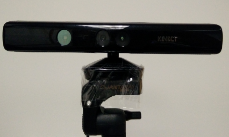



### Sensor inercial

El sensor  inercial portátil utilizado para esta base de datos consta de un sensor MEMS de 9 ejes que captura aceleración de 3 ejes, velocidad angular de 3 ejes y fuerza magnética de 3 ejes. La tasa de muestros de este sensor inercial portátil es de 50 Hz.

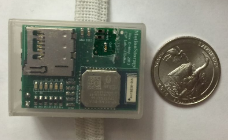

## Acciones humanas en la base de datos



La base de datos consiste de 27 diferentes acciones humanas:

1. Deslizar el brazo derecho hacia la izquierda
2. Deslizar el brazo derecho hacia la derecha
3. Saludar con la mano derecha
4. Aplaudir con las dos manos al frente
5. Lanzar con el brazo derecho
6. Cruzar los brazos sobre el pecho
7. Lanzamiento de baloncesto
8. Dibujar una X con la mano derecha
9. Dibujar un círculo con la mano derecha (sentido horario)
10. Dibujar un círculo con la mano derecha (sentido antihorario)
11. Dibujar un triángulo
12. Lanzamiento de bolos (con la mano derecha)
13. Boxeo al frente
14. Swing de béisbol desde la derecha
15. Golpe de forehand de tenis con la mano derecha
16. Curl de brazo (con ambos brazos)
17. Saque de tenis
18. Empujar con las dos manos
19. Llamar a la puerta con la mano derecha
20. Atrapar un objeto con la mano derecha
21. Recoger y lanzar con la mano derecha
22. Correr en el lugar
23. Caminar en el lugar
24. Sentarse a levantarse
25. Levantarse a sentarse
26. Zancada hacia adelante (con el pie izquierdo adelante)
27. Sentadilla (con los dos brazos estirados hacia afuera)

El sensor inercial se colocó en la mucheda derecha o en el muslo derecho del sujeto, dependiendo de si la acción era principalmente de brazo o pierna. Específicamente, para las acciones del 1 al 21, el sensor inercial se colocó en la muñeca derecha y para las acciones del 22 al 27, el sensor inercial se colocó en el muslo derecho del sujeto.

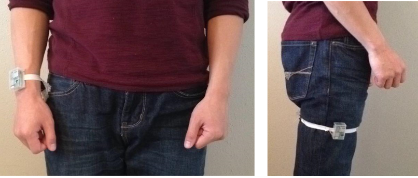

## Descripcion de los datos


La base de datos contiene 27 acciones realizadas por 8 personas (4 hombres y 4 mujeres). Cada persona repite las 27 acciones. Despues de remover 3 sequencias corruptas, la base de datos incluye 861 secuencias de datos. Se grabaron 4 tipos de datos: Videos en RGB, Videos de profundidad, posiciones de las articulaciones del esqueleto y las señales del sensor inercial en tres ejes.

# Carga de base de datos

In [1]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy.io import loadmat

#La base de datos esta en mi drive
from google.colab import drive
drive.mount('/content/drive')
pd.set_option('display.max_columns', None)

Mounted at /content/drive


## Esqueleto

In [2]:
video_file_skeleton = "/content/drive/MyDrive/Proyecto Reconocimiento/Skeleton/Skeleton"
skeleton_dfs = []

for file_name in os.listdir(video_file_skeleton):
    if file_name.endswith('_skeleton.mat'):
        action_id, person_id, test_id = map(int, [file_name.split('_')[0][1:], file_name.split('_')[1][1:], file_name.split('_')[2][1:]])
        mat_contents = loadmat(os.path.join(video_file_skeleton, file_name))
        if 'd_skel' in mat_contents:
            skeleton_data = np.transpose(mat_contents['d_skel'], (2, 0, 1))
            for frame_idx, frame in enumerate(skeleton_data):
                frame_data = frame.flatten().reshape(20, 3)
                frame_data = frame_data.flatten()
                multi_index = pd.MultiIndex.from_tuples([(action_id, person_id, test_id, frame_idx)], names=['action_id', 'person_id', 'test_id', 'frame_idx'])
                skeleton_dfs.append(pd.DataFrame([frame_data], columns=[f'point_{(i//3)+1}_{["x", "y", "z"][i%3]}' for i in range(60)], index=multi_index))

skeleton_df = pd.concat(skeleton_dfs)


In [ ]:
print(skeleton_df.head())
print(skeleton_df.shape)

                                       point_1_x  point_1_y  point_1_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0          -0.045763   0.483985   2.830189   
                            1          -0.045314   0.483987   2.830307   
                            2          -0.044791   0.483999   2.830396   
                            3          -0.044316   0.483995   2.830455   
                            4          -0.043912   0.483994   2.830503   

                                       point_2_x  point_2_y  point_2_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0          -0.034567   0.299454   2.877040   
                            1          -0.034429   0.299377   2.877029   
                            2          -0.034372   0.299287   2.876948   
                            3          -0.034331   0.299194   2.876836   
                            4        

<ipython-input-3-61089c9658f6>:27: PerformanceWarning: indexing past lexsort depth may impact performance.
  skeleton_plot(skeleton_df.loc[(1, 1, 1), :])


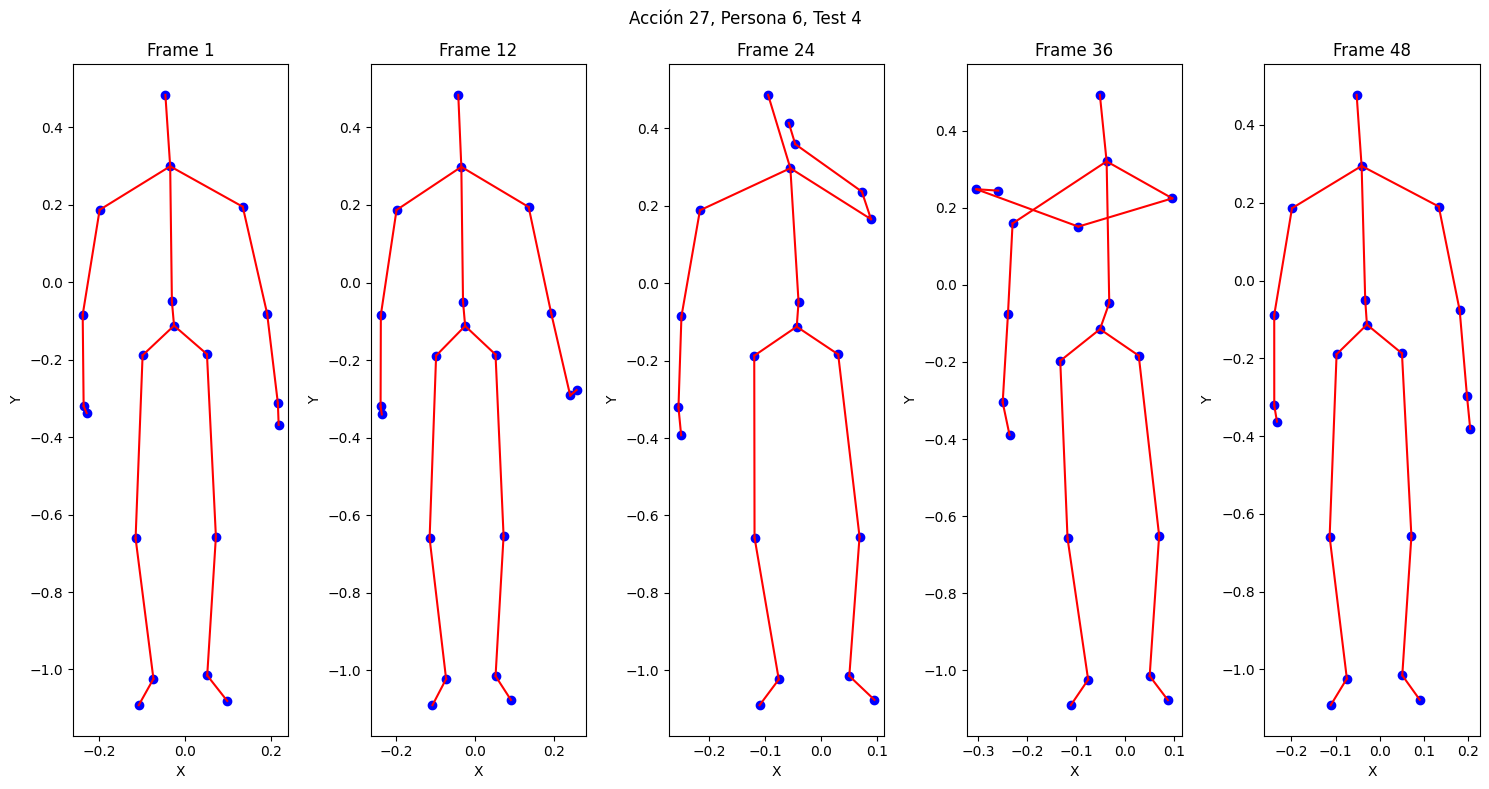

In [ ]:
connections = [
    (0, 1), (1, 2), (2, 3), (4, 5), (5, 6), (6, 7),
    (8, 9), (9, 10), (10, 11), (3, 12), (12, 13), (13, 14),
    (14, 15), (16, 17), (17, 18), (18, 19), (3, 16), (1, 4), (1, 8)
]

def skeleton_plot(example_frames):
    num_frames = 5
    frame_indices = np.linspace(0, len(example_frames)-1, num_frames, dtype=int)

    fig, axes = plt.subplots(1, num_frames, figsize=(15, 8))

    for idx, ax in zip(frame_indices, axes):
        coords = example_frames.iloc[idx].values.flatten().reshape(20, 3)
        ax.scatter(coords[:, 0], coords[:, 1], color='b')
        for start_idx, end_idx in connections:
            ax.plot([coords[start_idx, 0], coords[end_idx, 0]],
                    [coords[start_idx, 1], coords[end_idx, 1]], color='r')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'Frame {idx+1}')

    fig.suptitle(f'Acción {action_id}, Persona {person_id}, Test {test_id}')
    plt.tight_layout()
    plt.show()

skeleton_plot(skeleton_df.loc[(1, 1, 1), :])


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# connections = [
#     (0, 1), (1, 2), (2, 3), (4, 5), (5, 6), (6, 7),
#     (8, 9), (9, 10), (10, 11), (3, 12), (12, 13), (13, 14),
#     (14, 15), (16, 17), (17, 18), (18, 19), (3, 16), (1, 4), (1, 8)
# ]

# def skeleton_plot_3d(example_frames):
#     num_frames = 5
#     frame_indices = np.linspace(0, len(example_frames) - 1, num_frames, dtype=int)

#     fig = plt.figure(figsize=(15, 8))

#     for i, idx in enumerate(frame_indices):
#         ax = fig.add_subplot(1, num_frames, i + 1, projection='3d')
#         coords = example_frames.iloc[idx].values.flatten().reshape(20, 3)

#         ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], color='b')  # X, Y, Z

#         for start_idx, end_idx in connections:
#             ax.plot([coords[start_idx, 2], coords[end_idx, 2]], [coords[start_idx, 0], coords[end_idx, 0]],  # X
#                     [coords[start_idx, 1], coords[end_idx, 1]],  # Y
#                      # Z
#                     color='r')

#         ax.set_xlabel('X')
#         ax.set_ylabel('Y')
#         ax.set_zlabel('Z')
#         ax.set_title(f'Frame {idx+1}')
#         ax.view_init(elev=20, azim=30)  # Ajusta la vista

#     fig.suptitle(f'Acción {action_id}, Persona {person_id}, Test {test_id}')
#     plt.tight_layout()
#     plt.show()

# skeleton_plot_3d(skeleton_df.loc[(1, 1, 1), :])


## Inertial

In [3]:
inertial_data_path = "/content/drive/MyDrive/Proyecto Reconocimiento/Inertial/Inertial"
inertial_dfs = []

for file_name in os.listdir(inertial_data_path):
    if file_name.endswith('_inertial.mat'):
        action_id, person_id, test_id = map(int, [file_name.split('_')[0][1:], file_name.split('_')[1][1:], file_name.split('_')[2][1:]])
        mat_contents = loadmat(os.path.join(inertial_data_path, file_name))
        if 'd_iner' in mat_contents:
            inertial_data = mat_contents['d_iner']
            inertial_data_reshaped = np.array([x.flatten() for x in inertial_data])
            for frame_idx, frame_data in enumerate(inertial_data_reshaped):
                multi_index = pd.MultiIndex.from_tuples([(action_id, person_id, test_id, frame_idx)], names=['action_id', 'person_id', 'test_id', 'frame_idx'])
                inertial_dfs.append(pd.DataFrame([frame_data], columns=["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"], index=multi_index))

inertial_df = pd.concat(inertial_dfs)
print(inertial_df.head())
print(inertial_df.shape)


                                          acc_x     acc_y     acc_z  \
action_id person_id test_id frame_idx                                 
1         1         1       0         -0.959473 -0.177734 -0.192871   
                            1         -0.961914 -0.153320 -0.159912   
                            2         -0.974609 -0.152832 -0.145996   
                            3         -0.941895 -0.135742 -0.127930   
                            4         -0.958252 -0.201416 -0.139404   

                                          gyro_x    gyro_y    gyro_z  
action_id person_id test_id frame_idx                                 
1         1         1       0           5.221374  1.526718  0.152672  
                            1           6.778626  1.954198  0.244275  
                            2          11.267176  3.175573  1.099237  
                            3          16.885496  4.732824  2.320611  
                            4          16.030534  4.000000  0.366412  
(1556

<ipython-input-22-3f9b25ae04b8>:26: PerformanceWarning: indexing past lexsort depth may impact performance.
  plot_inertial_data(inertial_df.loc[(1,1,1), :])


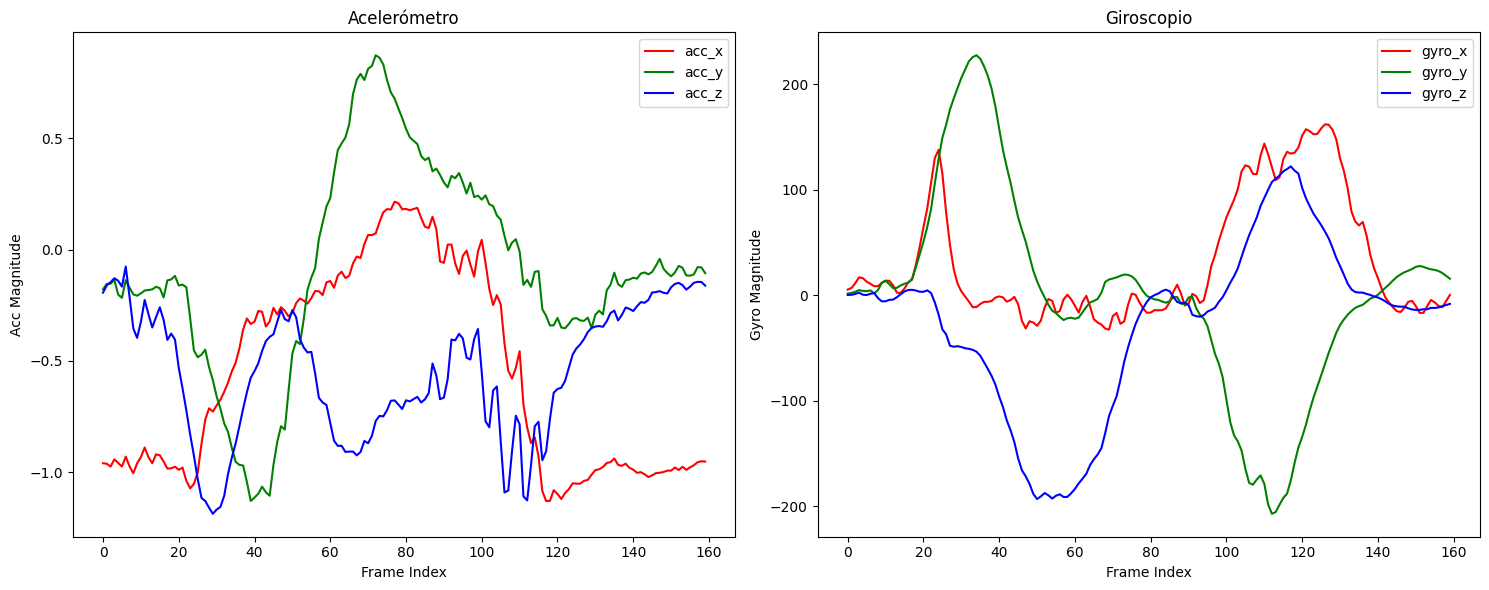

In [ ]:
def plot_inertial_data(example_data):
    acc_data = example_data[["acc_x", "acc_y", "acc_z"]]
    gyro_data = example_data[["gyro_x", "gyro_y", "gyro_z"]]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].plot(acc_data.index, acc_data["acc_x"], label='acc_x', color='r')
    axes[0].plot(acc_data.index, acc_data["acc_y"], label='acc_y', color='g')
    axes[0].plot(acc_data.index, acc_data["acc_z"], label='acc_z', color='b')
    axes[0].set_title('Acelerómetro')
    axes[0].set_xlabel('Frame Index')
    axes[0].set_ylabel('Acc Magnitude')
    axes[0].legend()

    axes[1].plot(gyro_data.index, gyro_data["gyro_x"], label='gyro_x', color='r')
    axes[1].plot(gyro_data.index, gyro_data["gyro_y"], label='gyro_y', color='g')
    axes[1].plot(gyro_data.index, gyro_data["gyro_z"], label='gyro_z', color='b')
    axes[1].set_title('Giroscopio')
    axes[1].set_xlabel('Frame Index')
    axes[1].set_ylabel('Gyro Magnitude')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_inertial_data(inertial_df.loc[(1,1,1), :])


## Guardamos todo en un solo df

In [ ]:
final_df = skeleton_df.merge(inertial_df, how="outer", left_index=True, right_index=True)
print(final_df.head())
print(final_df.shape)

                                       point_1_x  point_1_y  point_1_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0          -0.045763   0.483985   2.830189   
                            1          -0.045314   0.483987   2.830307   
                            2          -0.044791   0.483999   2.830396   
                            3          -0.044316   0.483995   2.830455   
                            4          -0.043912   0.483994   2.830503   

                                       point_2_x  point_2_y  point_2_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0          -0.034567   0.299454   2.877040   
                            1          -0.034429   0.299377   2.877029   
                            2          -0.034372   0.299287   2.876948   
                            3          -0.034331   0.299194   2.876836   
                            4        

# Identifica y elimina los datos ausentes.

In [ ]:
skeleton_df.isnull().sum()
#datos ausentes, ya eliminados por el de la base de datos:
# Remove the corrupted data file names
# file_namelist.remove('a8_s1_t4')
# file_namelist.remove('a23_s6_t4')
# file_namelist.remove('a27_s8_t4')

,0
point_1_x,0
point_1_y,0
point_1_z,0
point_2_x,0
point_2_y,0
point_2_z,0
point_3_x,0
point_3_y,0
point_3_z,0
point_4_x,0


In [ ]:
inertial_df.isnull().sum()

,0
acc_x,0
acc_y,0
acc_z,0
gyro_x,0
gyro_y,0
gyro_z,0


# Presenta los tipos de datos de cada atributo de cada base de datos.

In [ ]:
print(skeleton_df.dtypes)

point_1_x     float64
point_1_y     float64
point_1_z     float64
point_2_x     float64
point_2_y     float64
point_2_z     float64
point_3_x     float64
point_3_y     float64
point_3_z     float64
point_4_x     float64
point_4_y     float64
point_4_z     float64
point_5_x     float64
point_5_y     float64
point_5_z     float64
point_6_x     float64
point_6_y     float64
point_6_z     float64
point_7_x     float64
point_7_y     float64
point_7_z     float64
point_8_x     float64
point_8_y     float64
point_8_z     float64
point_9_x     float64
point_9_y     float64
point_9_z     float64
point_10_x    float64
point_10_y    float64
point_10_z    float64
point_11_x    float64
point_11_y    float64
point_11_z    float64
point_12_x    float64
point_12_y    float64
point_12_z    float64
point_13_x    float64
point_13_y    float64
point_13_z    float64
point_14_x    float64
point_14_y    float64
point_14_z    float64
point_15_x    float64
point_15_y    float64
point_15_z    float64
point_16_x

In [ ]:
print(inertial_df.dtypes)

acc_x     float64
acc_y     float64
acc_z     float64
gyro_x    float64
gyro_y    float64
gyro_z    float64
dtype: object


# Presenta el resumen estadístico de cada uno de los atributos de cada base de datos

In [ ]:
stats = final_df.describe()
print(stats)
stats2 = final_df.groupby(level=['action_id']).describe()
#print(stats2)

          point_1_x     point_1_y     point_1_z     point_2_x     point_2_y  \
count  58299.000000  58299.000000  58299.000000  58299.000000  58299.000000   
mean      -0.095496      0.453867      2.881422     -0.090920      0.268885   
std        0.052126      0.163035      0.127305      0.045769      0.156211   
min       -0.344944     -0.584201      2.250838     -0.304446     -0.696218   
25%       -0.123736      0.389571      2.834122     -0.114911      0.206500   
50%       -0.100467      0.428504      2.862811     -0.094696      0.250983   
75%       -0.075229      0.535668      2.899104     -0.073353      0.350859   
max        0.192717      0.822258      3.584473      0.153682      0.654998   

          point_2_z     point_3_x     point_3_y     point_3_z     point_4_x  \
count  58299.000000  58299.000000  58299.000000  58299.000000  58299.000000   
mean       2.899522     -0.084452     -0.070403      2.916187     -0.083083   
std        0.124685      0.039323      0.128158    

In [ ]:
df_inertial_stats = inertial_df.groupby(level=['action_id']).agg(['mean', 'std', 'min', 'max'])
df_inertial_stats.columns = ['_'.join(col).strip() for col in df_inertial_stats.columns]
df_inertial_stats.reset_index(inplace=True)
df_inertial_stats = inertial_df.groupby(level=['action_id']).describe()

df_inertial_stats

acc_x                                                              \
            count      mean       std       min       25%       50%       75%   
action_id                                                                       
1          5150.0 -0.681132  0.474991 -2.056641 -1.017273 -0.932251 -0.225891   
2          4984.0 -0.612619  0.532934 -2.650879 -1.008301 -0.766724 -0.166687   
3          5587.0 -0.427396  0.739399 -2.638184 -1.008057 -0.571533  0.219726   
4          5215.0 -0.351023  0.844269 -6.413330 -1.004272 -0.684570  0.420532   
5          4990.0 -0.559946  0.835680 -8.000000 -1.028564 -0.913574  0.110657   
6          5496.0 -0.438578  0.730646 -2.233154 -1.006592 -0.898560  0.376160   
7          5147.0 -0.411935  0.827712 -4.242676 -1.012695 -0.833252  0.338379   
8          5387.0 -0.797434  0.660279 -5.337402 -1.085694 -0.954102 -0.330688   
9          6327.0 -0.587177  0.664010 -4.104492 -1.002930 -0.752930 -0.111938   
10         6208.0 -0.584895  0.595004 -3.293213 -1.013916 -0.700806 -0.075928   
11         6432.0 -0.475621  0.626057 -3.163574 -0.991211 -0.532471  0.095581   
12         6801.0 -1.136171  0.855410 -8.000000 -1.102295 -0.994141 -0.889404   
13         5719.0 -0.382762  1.031352 -7.560059 -1.018066 -0.772705  0.378296   
14         6453.0 -0.707789  0.948927 -7.954102 -1.040527 -0.915039 -0.120850   
15         5632.0 -1.129536  1.253562 -8.000000 -1.194397 -0.991211 -0.620056   
16         4993.0 -0.497266  0.770982 -2.237793 -1.008545 -0.952637  0.241699   
17         5897.0 -0.760401  0.781200 -8.000000 -1.028564 -0.952881 -0.472656   
18         5206.0 -0.440200  0.728737 -2.449707 -1.005615 -0.665771  0.057617   
19         5801.0 -0.259398  0.847462 -2.960205 -0.997803 -0.229736  0.508545   
20         4999.0 -0.345874  0.804581 -3.972168 -1.001587 -0.530762  0.414062   
21         7473.0 -0.728668  0.699102 -5.639648 -1.100830 -0.932617 -0.363281   
22         5563.0 -1.000618  0.546590 -6.909668 -1.131225 -0.977051 -0.851074   
23         6214.0 -0.992321  0.199758 -2.854980 -1.009766 -0.975342 -0.928955   
24         4782.0 -0.679803  0.328549 -1.075439 -0.971924 -0.855103 -0.316162   
25         5051.0 -0.558298  0.315639 -1.433105 -0.919678 -0.443115 -0.290527   
26         7318.0 -0.980163  0.102604 -1.584717 -1.022644 -0.973877 -0.930664   
27         6813.0 -0.873857  0.162226 -1.754639 -0.987793 -0.952148 -0.797119   

                      acc_y                                                    \
                max   count      mean       std       min       25%       50%   
action_id                                                                       
1          0.550293  5150.0 -0.258435  0.540640 -1.938965 -0.627136 -0.240845   
2          1.064697  4984.0 -0.196362  0.521052 -2.332764 -0.474915 -0.216919   
3          1.261719  5587.0 -0.180902  0.922682 -3.278320 -0.687866 -0.259277   
4          3.652832  5215.0 -0.487909  0.437981 -4.066162 -0.735962 -0.432861   
5          1.650879  4990.0 -0.252270  0.644678 -8.000000 -0.529236 -0.228882   
6          1.047607  5496.0 -0.551069  0.333033 -1.859863 -0.746582 -0.532715   
7          2.336914  5147.0 -0.185098  0.612408 -3.298828 -0.473144 -0.181396   
8          0.957764  5387.0 -0.350314  0.554552 -4.844238 -0.573365 -0.273438   
9          1.224609  6327.0 -0.315228  0.502539 -2.591553 -0.581543 -0.275635   
10         0.706299  6208.0 -0.344356  0.547199 -2.989746 -0.666016 -0.296143   
11         0.842285  6432.0 -0.239504  0.526023 -3.985352 -0.543457 -0.196655   
12         0.546143  6801.0 -0.205623  0.298683 -2.518799 -0.363037 -0.181885   
13         2.662842  5719.0 -0.348653  0.507951 -3.497070 -0.633667 -0.302979   
14         1.295898  6453.0 -0.502086  0.732143 -5.069336 -0.885498 -0.496826   
15         1.019775  5632.0 -0.312386  0.484486 -2.521973 -0.581360 -0.300903   
16         1.521973  4993.0 -0.376161  0.380125 -1.948730 -0.599121 -0.337402   
17         2.019043  5897.0 -0.348779  0.5

# Presenta la distribución de clases de cada base de datos.

Notamos que la distribución de clases es desigual, lo que puede ser un problema segun especifica Seema S.Yandav y Girsh P. Bhole en su articulo titulado " Learning from Imbalanced Data in Classification"

In [14]:
class_distribution = inertial_df.groupby(level='action_id').size()
print(class_distribution)


class_distribution = inertial_df.groupby(['action_id', 'person_id', 'test_id']).size()

# Mostrar la distribución de clases
print(class_distribution)


action_id
1     5150
2     4984
3     5587
4     5215
5     4990
6     5496
7     5147
8     5387
9     6327
10    6208
11    6432
12    6801
13    5719
14    6453
15    5632
16    4993
17    5897
18    5206
19    5801
20    4999
21    7473
22    5563
23    6214
24    4782
25    5051
26    7318
27    6813
dtype: int64
action_id  person_id  test_id
1          1          1          160
                      2          154
                      3          165
                      4          158
           2          1          142
                                ... 
27         7          3          186
                      4          187
           8          1          266
                      2          258
                      3          255
Length: 861, dtype: int64


# Presenta la correlación entre atributos de cada base de datos

In [ ]:
final_correlation = final_df.iloc[:, :].corr(method = "pearson")
print(final_correlation)

           point_1_x  point_1_y  point_1_z  point_2_x  point_2_y  point_2_z  \
point_1_x   1.000000  -0.080766  -0.012733   0.923303  -0.077215   0.012447   
point_1_y  -0.080766   1.000000   0.136048  -0.044619   0.993291   0.044950   
point_1_z  -0.012733   0.136048   1.000000   0.006725   0.123619   0.969752   
point_2_x   0.923303  -0.044619   0.006725   1.000000  -0.042342   0.015615   
point_2_y  -0.077215   0.993291   0.123619  -0.042342   1.000000   0.037651   
...              ...        ...        ...        ...        ...        ...   
acc_y       0.018236  -0.013525   0.010540   0.009531  -0.011801   0.033734   
acc_z       0.028383  -0.089631   0.062241   0.018453  -0.095517   0.077462   
gyro_x      0.061968  -0.040153  -0.010323   0.015356  -0.046185   0.008328   
gyro_y      0.005392   0.035743  -0.019714   0.008041   0.045391  -0.044216   
gyro_z      0.052613  -0.055100  -0.012739   0.031286  -0.067743   0.036746   

           point_3_x  point_3_y  point_3_z  point_4

# Presenta el histograma de los atributos de cada base de datos

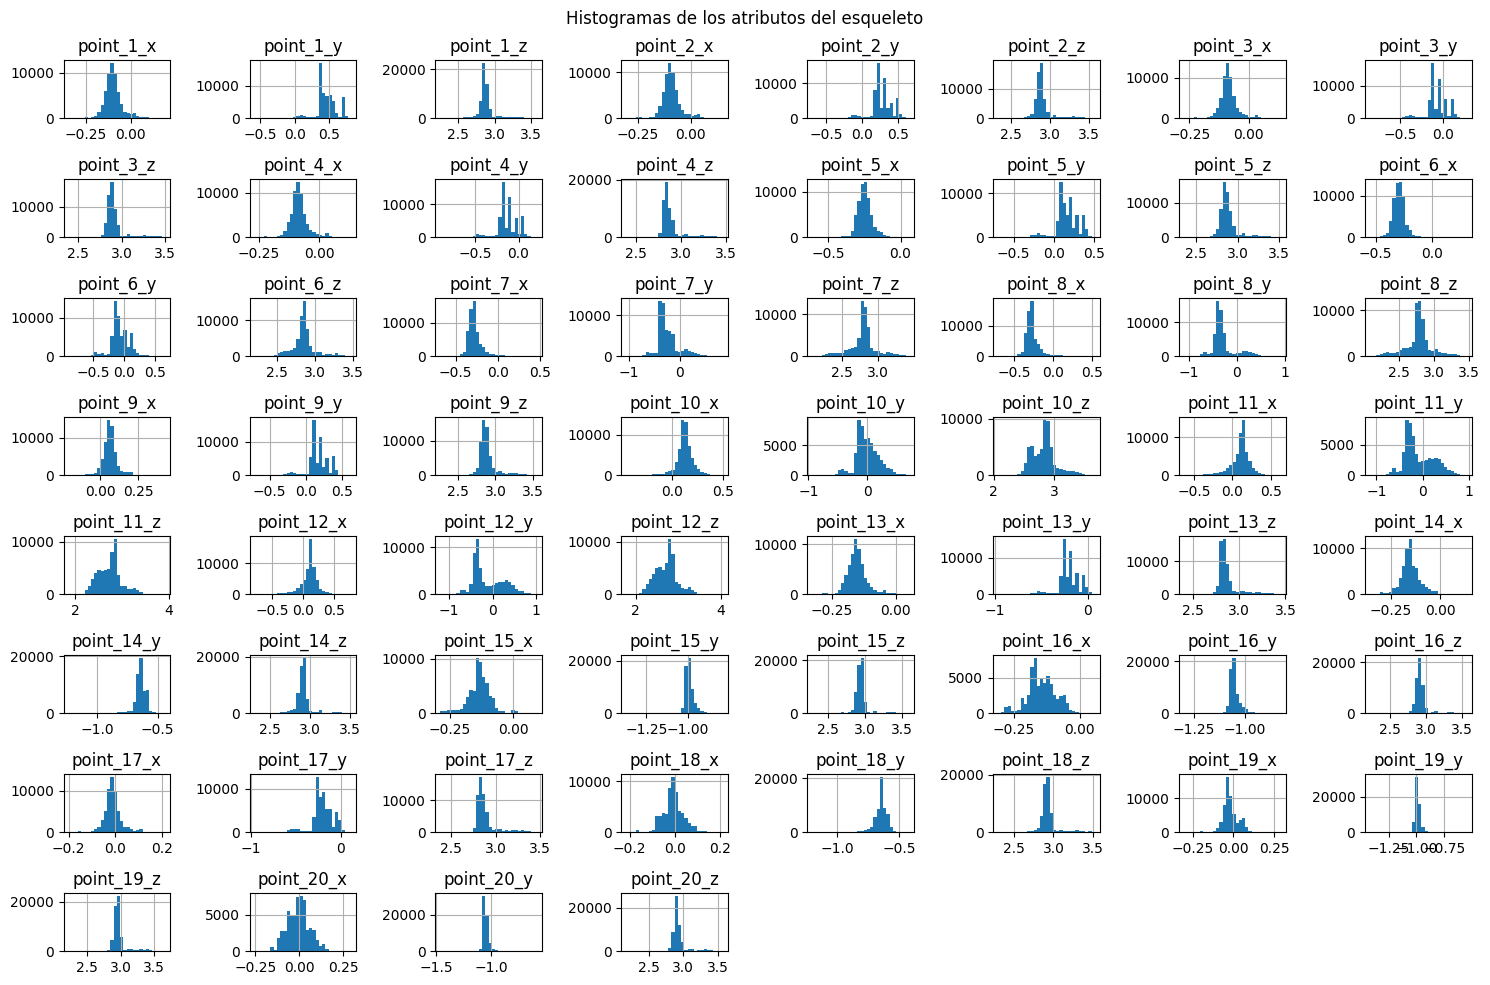

In [ ]:
import matplotlib.pyplot as plt


skeleton_df.hist(bins=30, figsize=(15, 10))


plt.xlim(-10, 10)

plt.suptitle("Histogramas de los atributos del esqueleto")
plt.tight_layout()
plt.show()


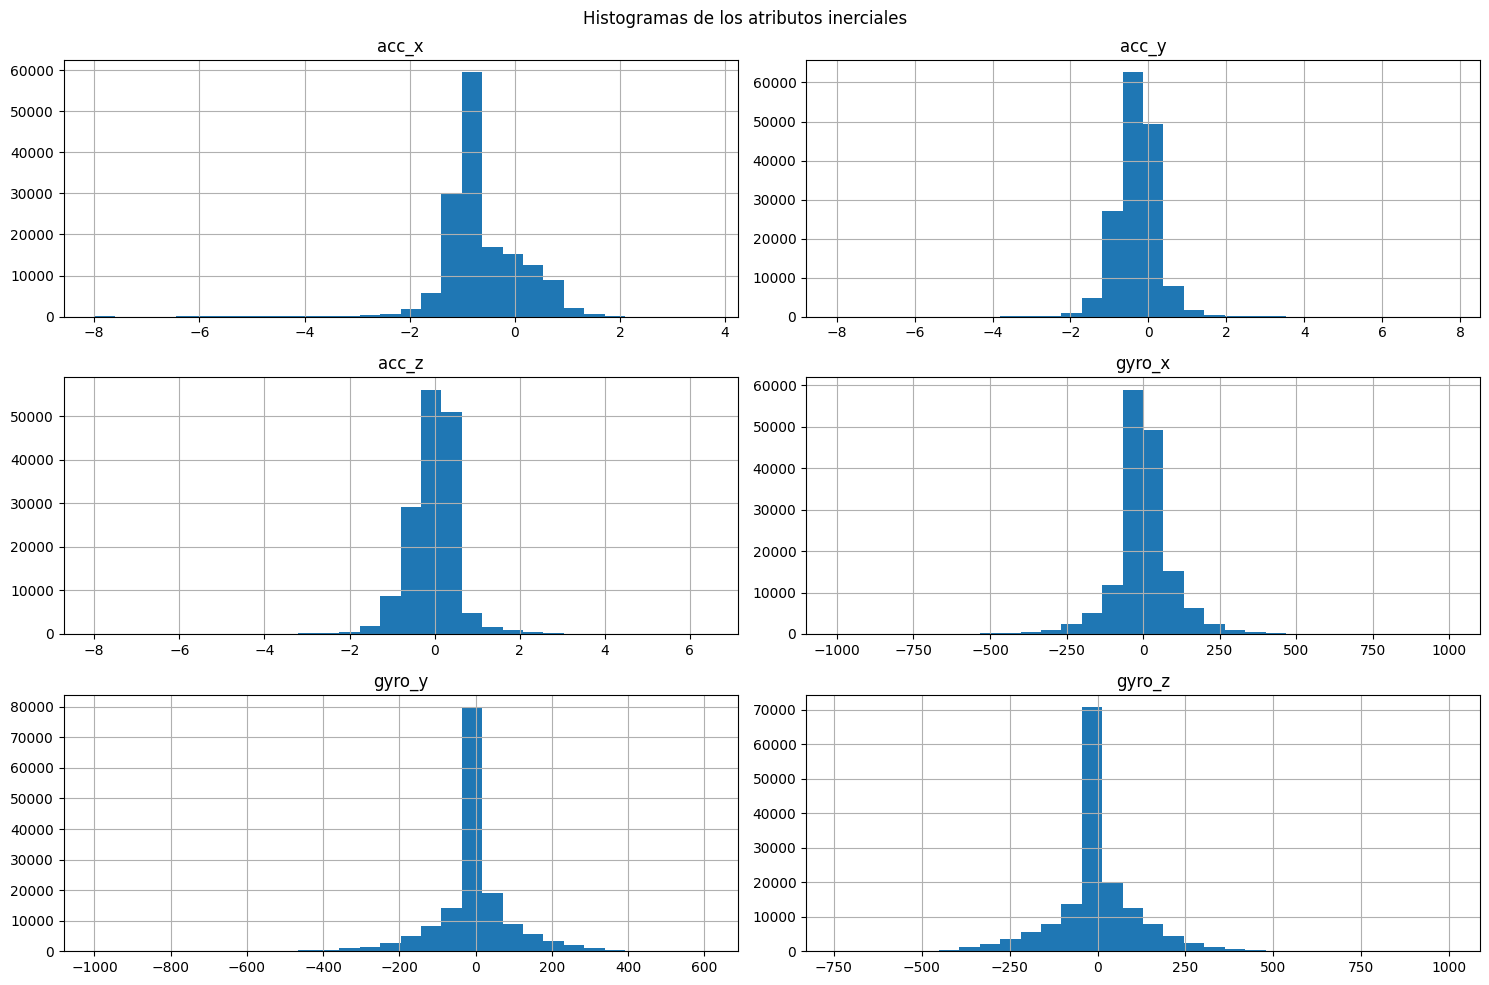

In [ ]:
inertial_df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogramas de los atributos inerciales")
plt.tight_layout()
plt.show()

# Diagramas de densidad

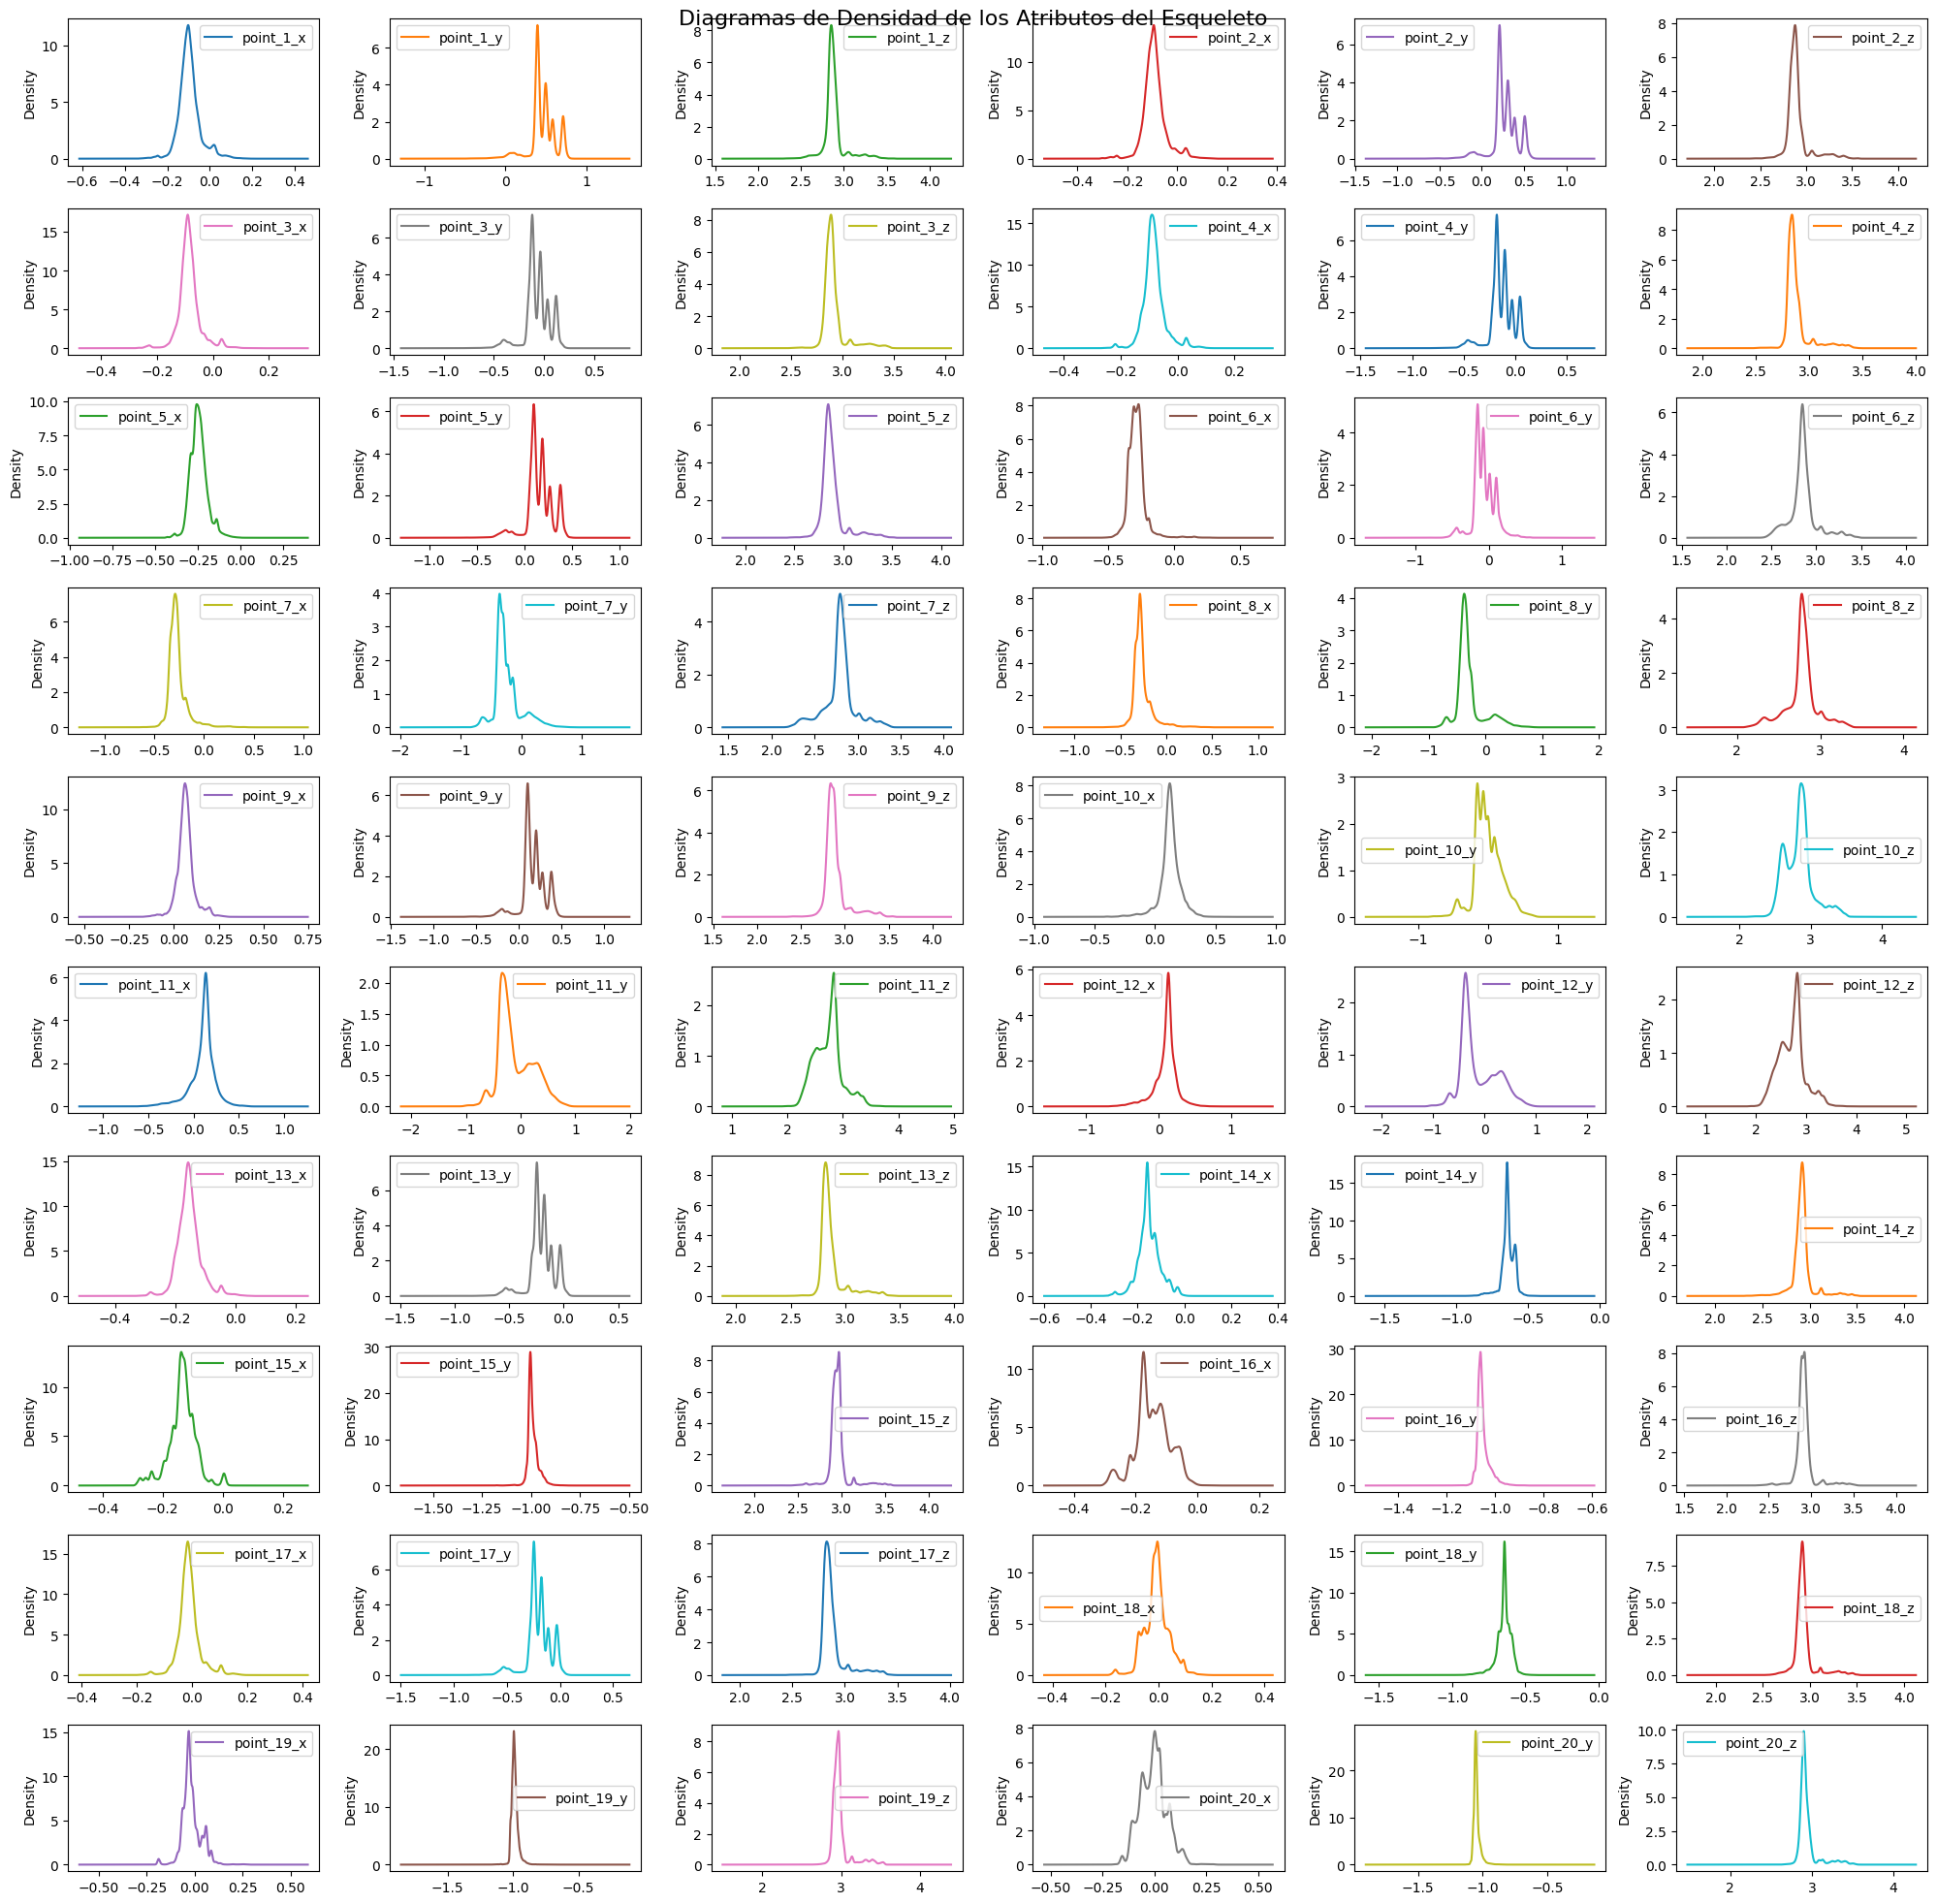

In [ ]:
skeleton_df.plot(kind='density', subplots=True, layout=(10, 6), figsize=(20, 20), sharex=False)


plt.suptitle("Diagramas de Densidad de los Atributos del Esqueleto", fontsize=16)
plt.tight_layout()
plt.show()



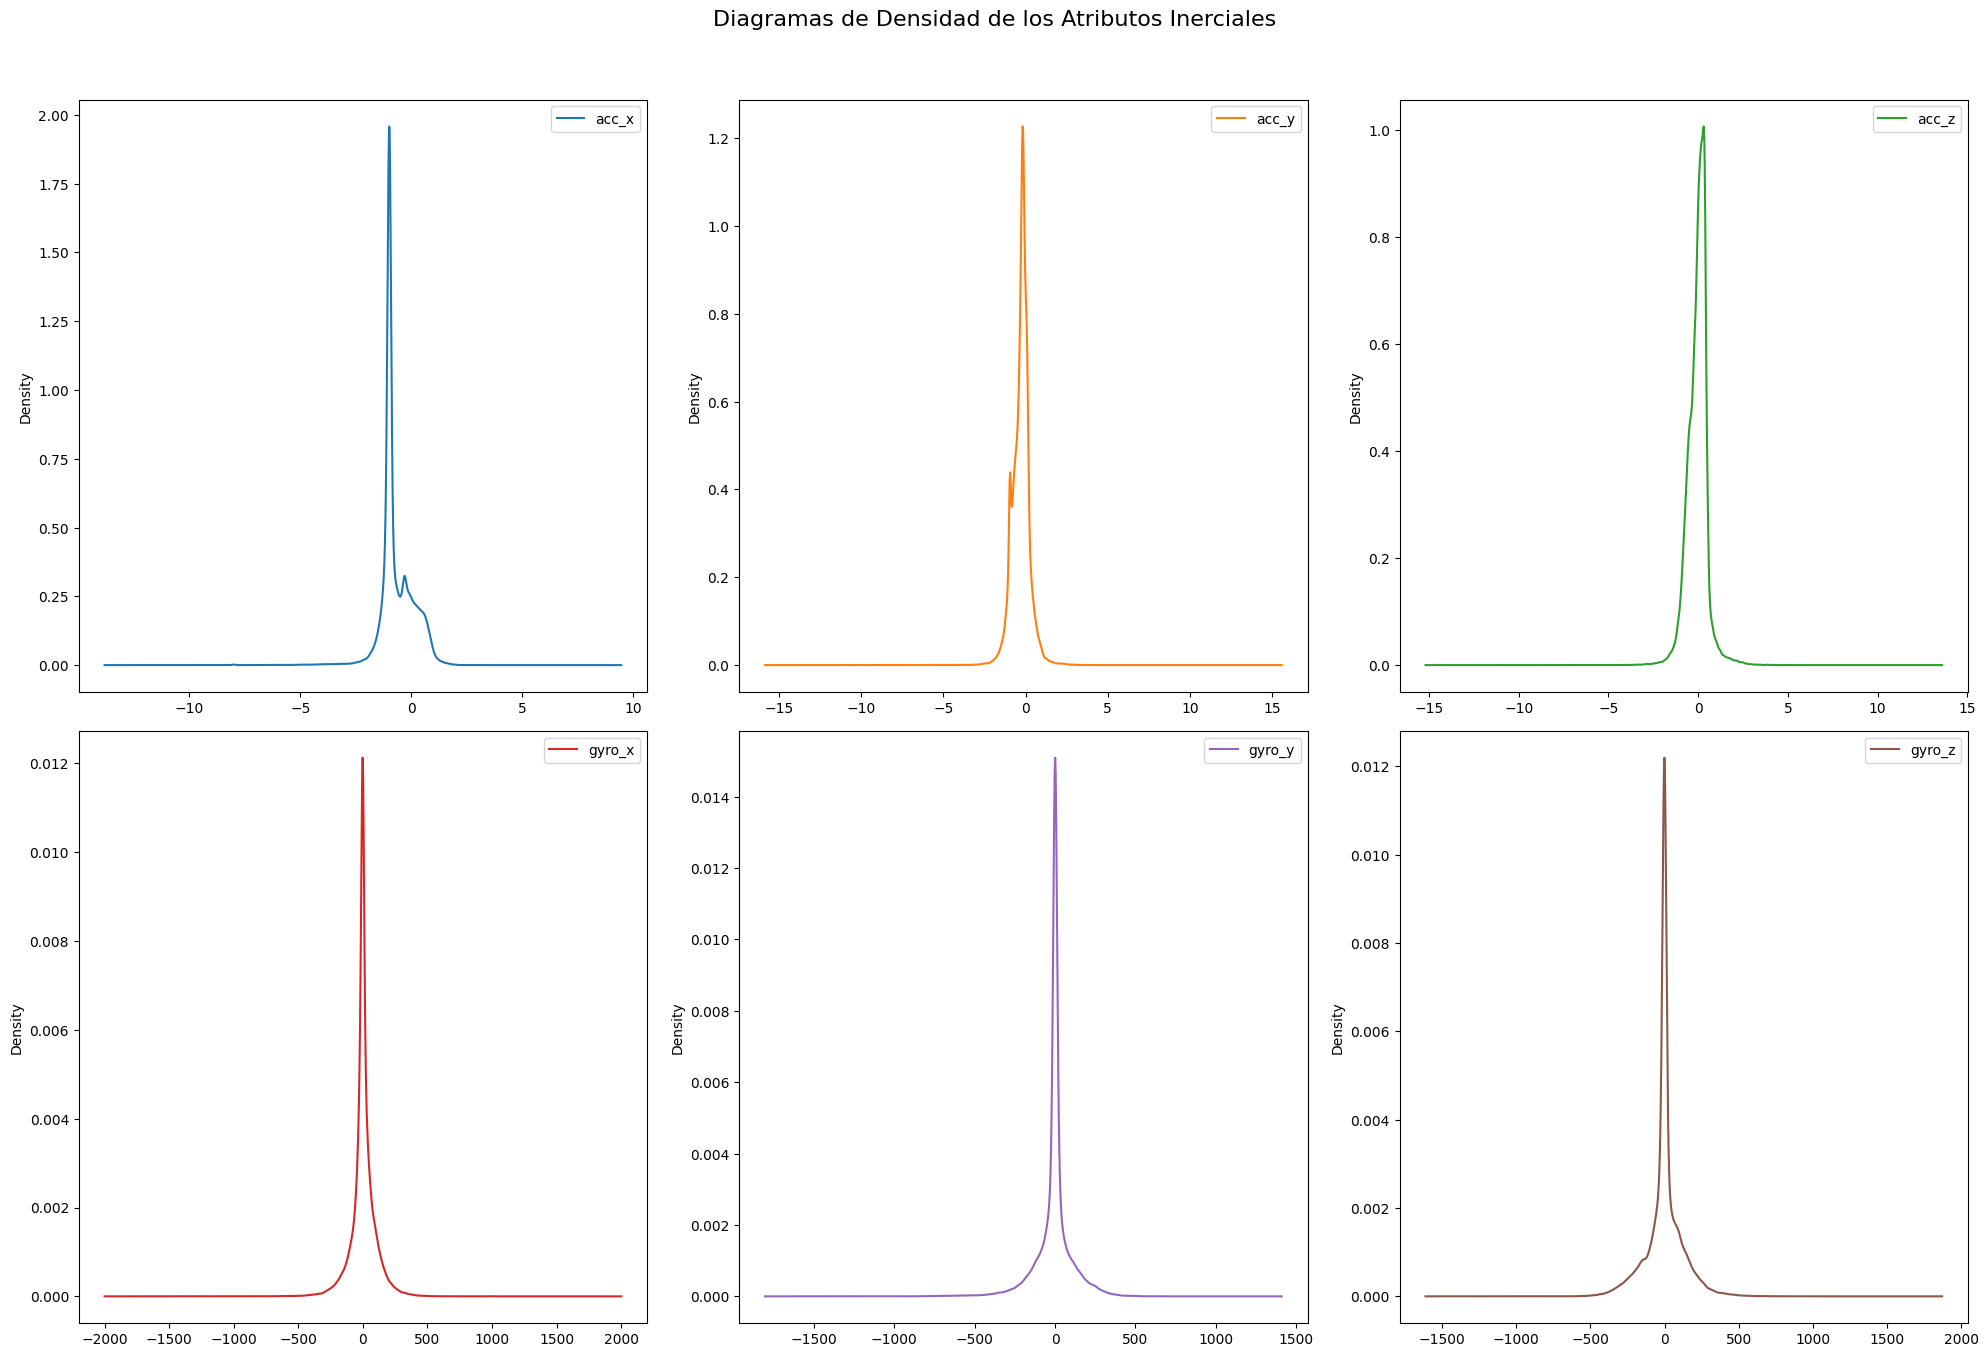

In [ ]:
inertial_df.plot(kind='density', subplots=True, layout=(3, 3), figsize=(20, 20), sharex=False)
plt.suptitle("Diagramas de Densidad de los Atributos Inerciales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos

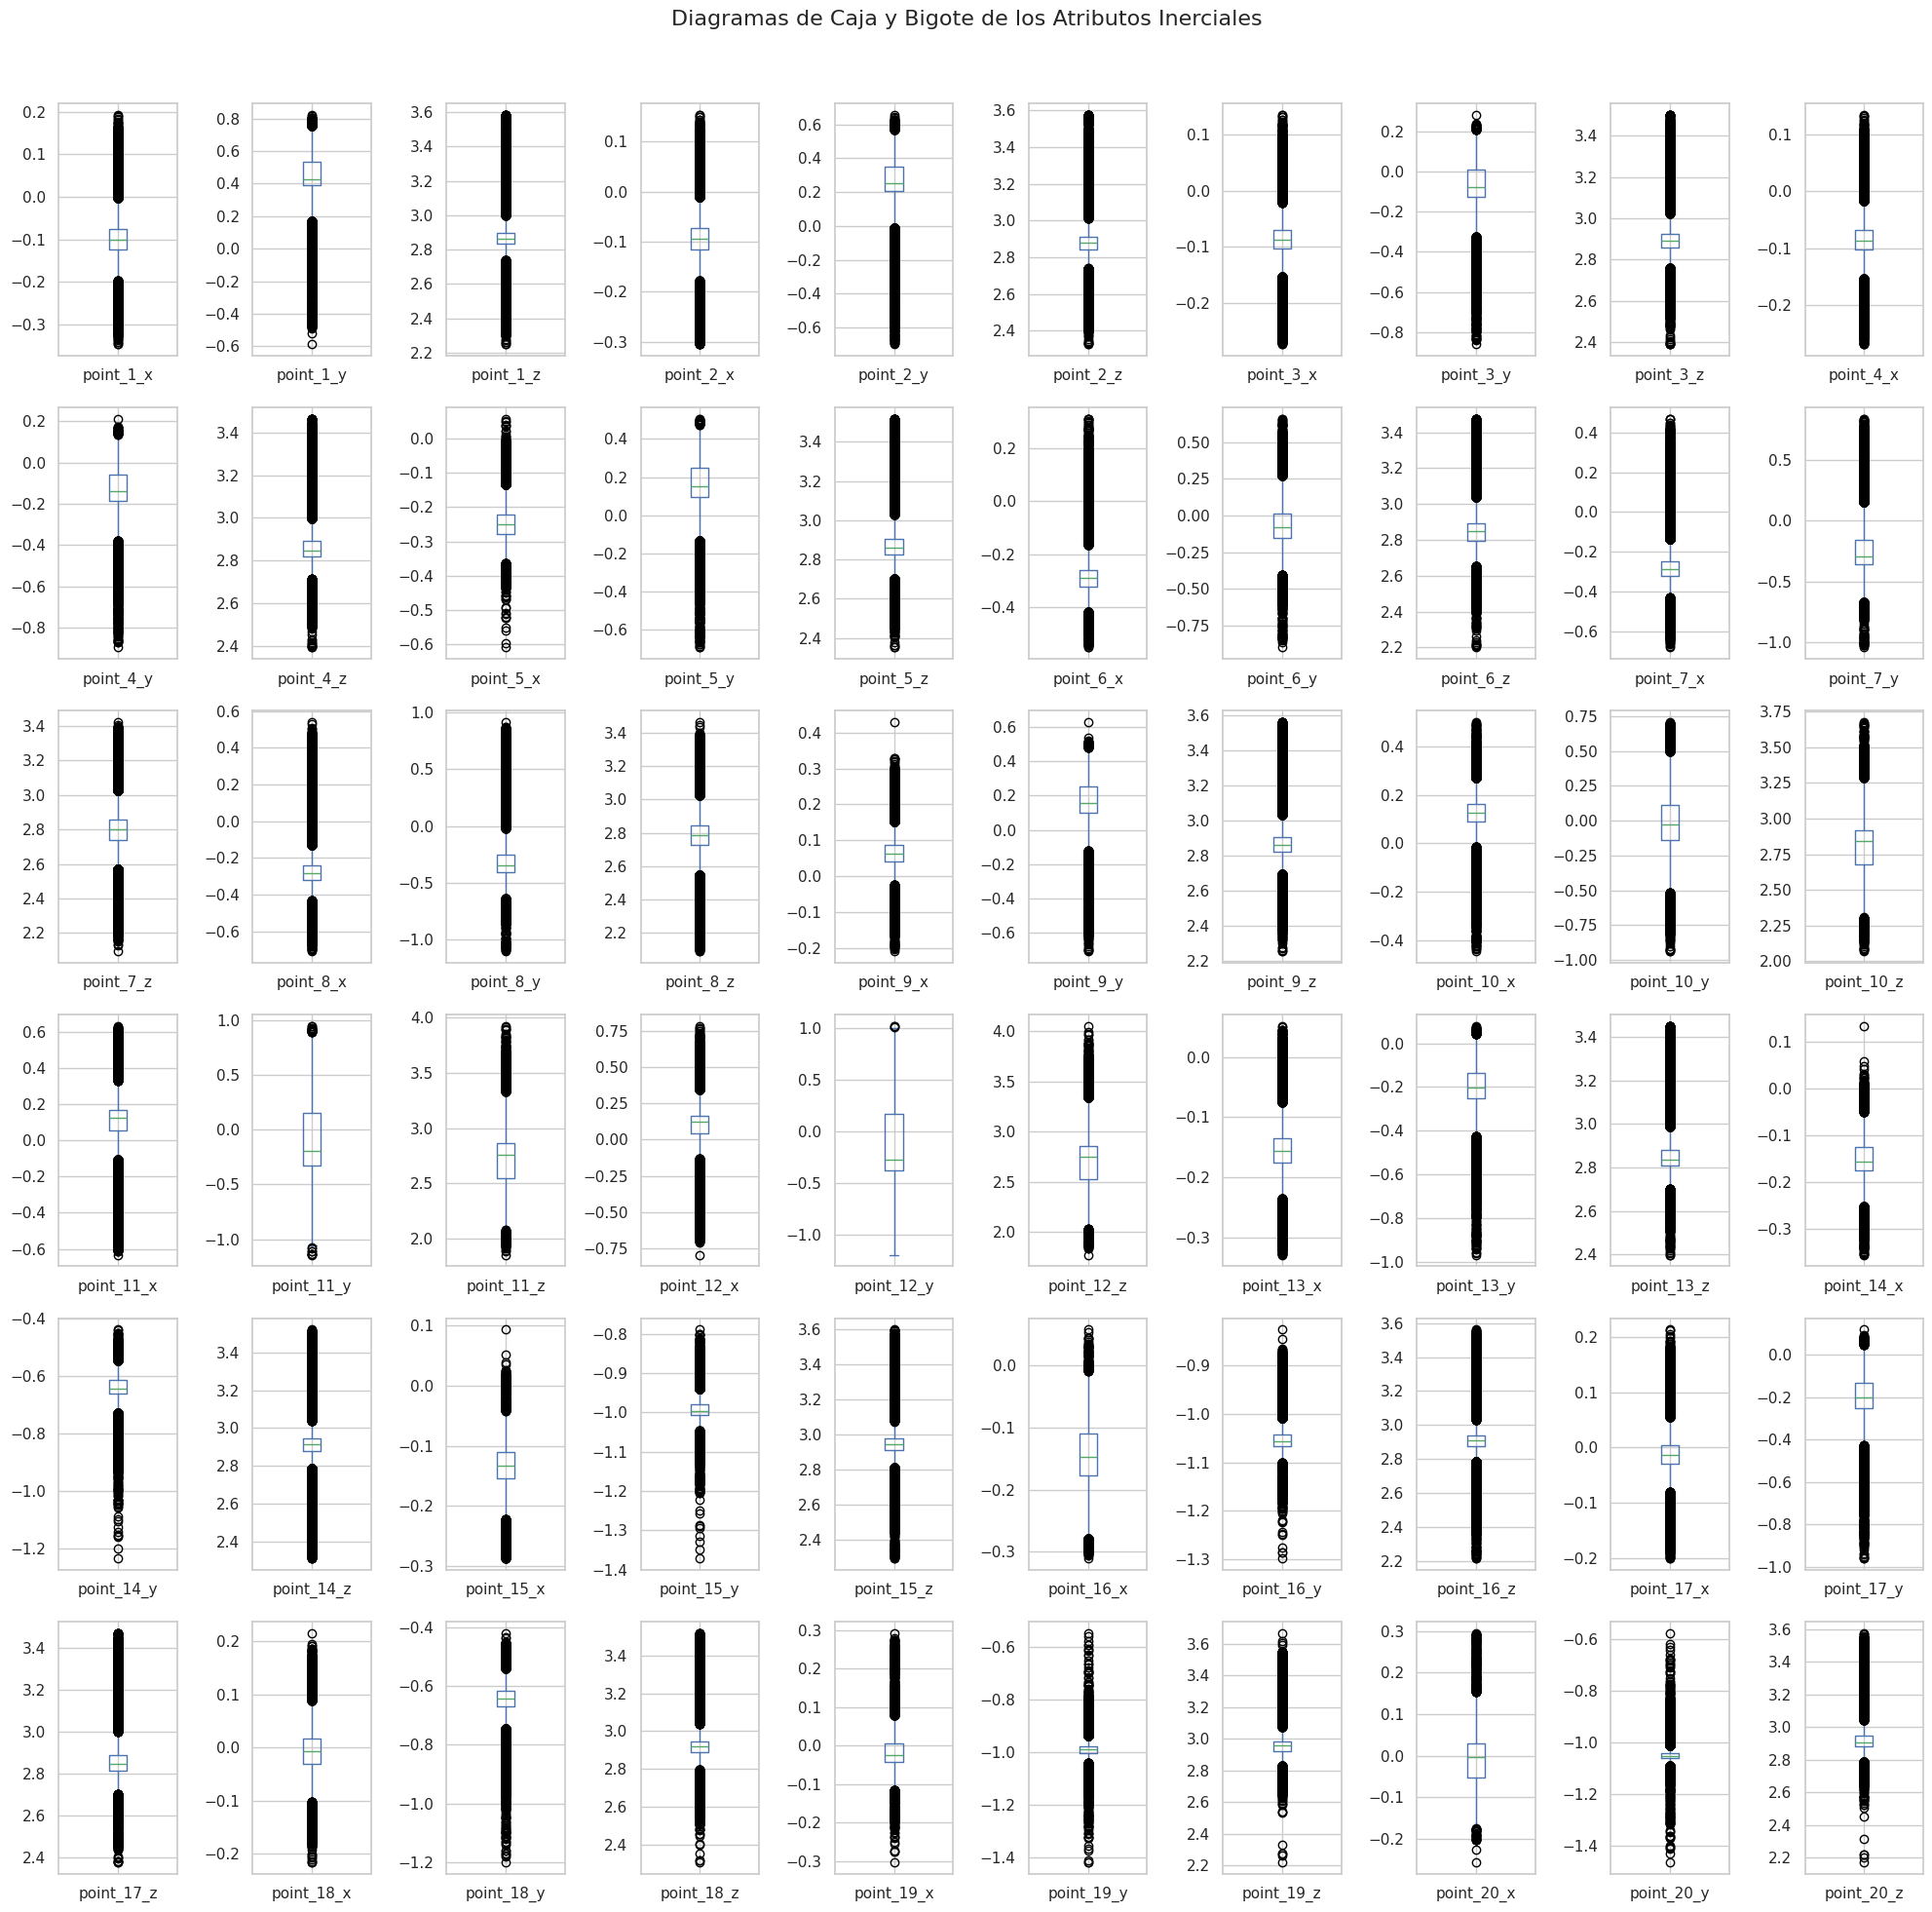

In [ ]:
sns.set(style="whitegrid")

skeleton_df.plot(kind='box', subplots=True, layout=(6, 10), figsize=(20, 20), sharex=False)
plt.suptitle("Diagramas de Caja y Bigote de los Atributos Inerciales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

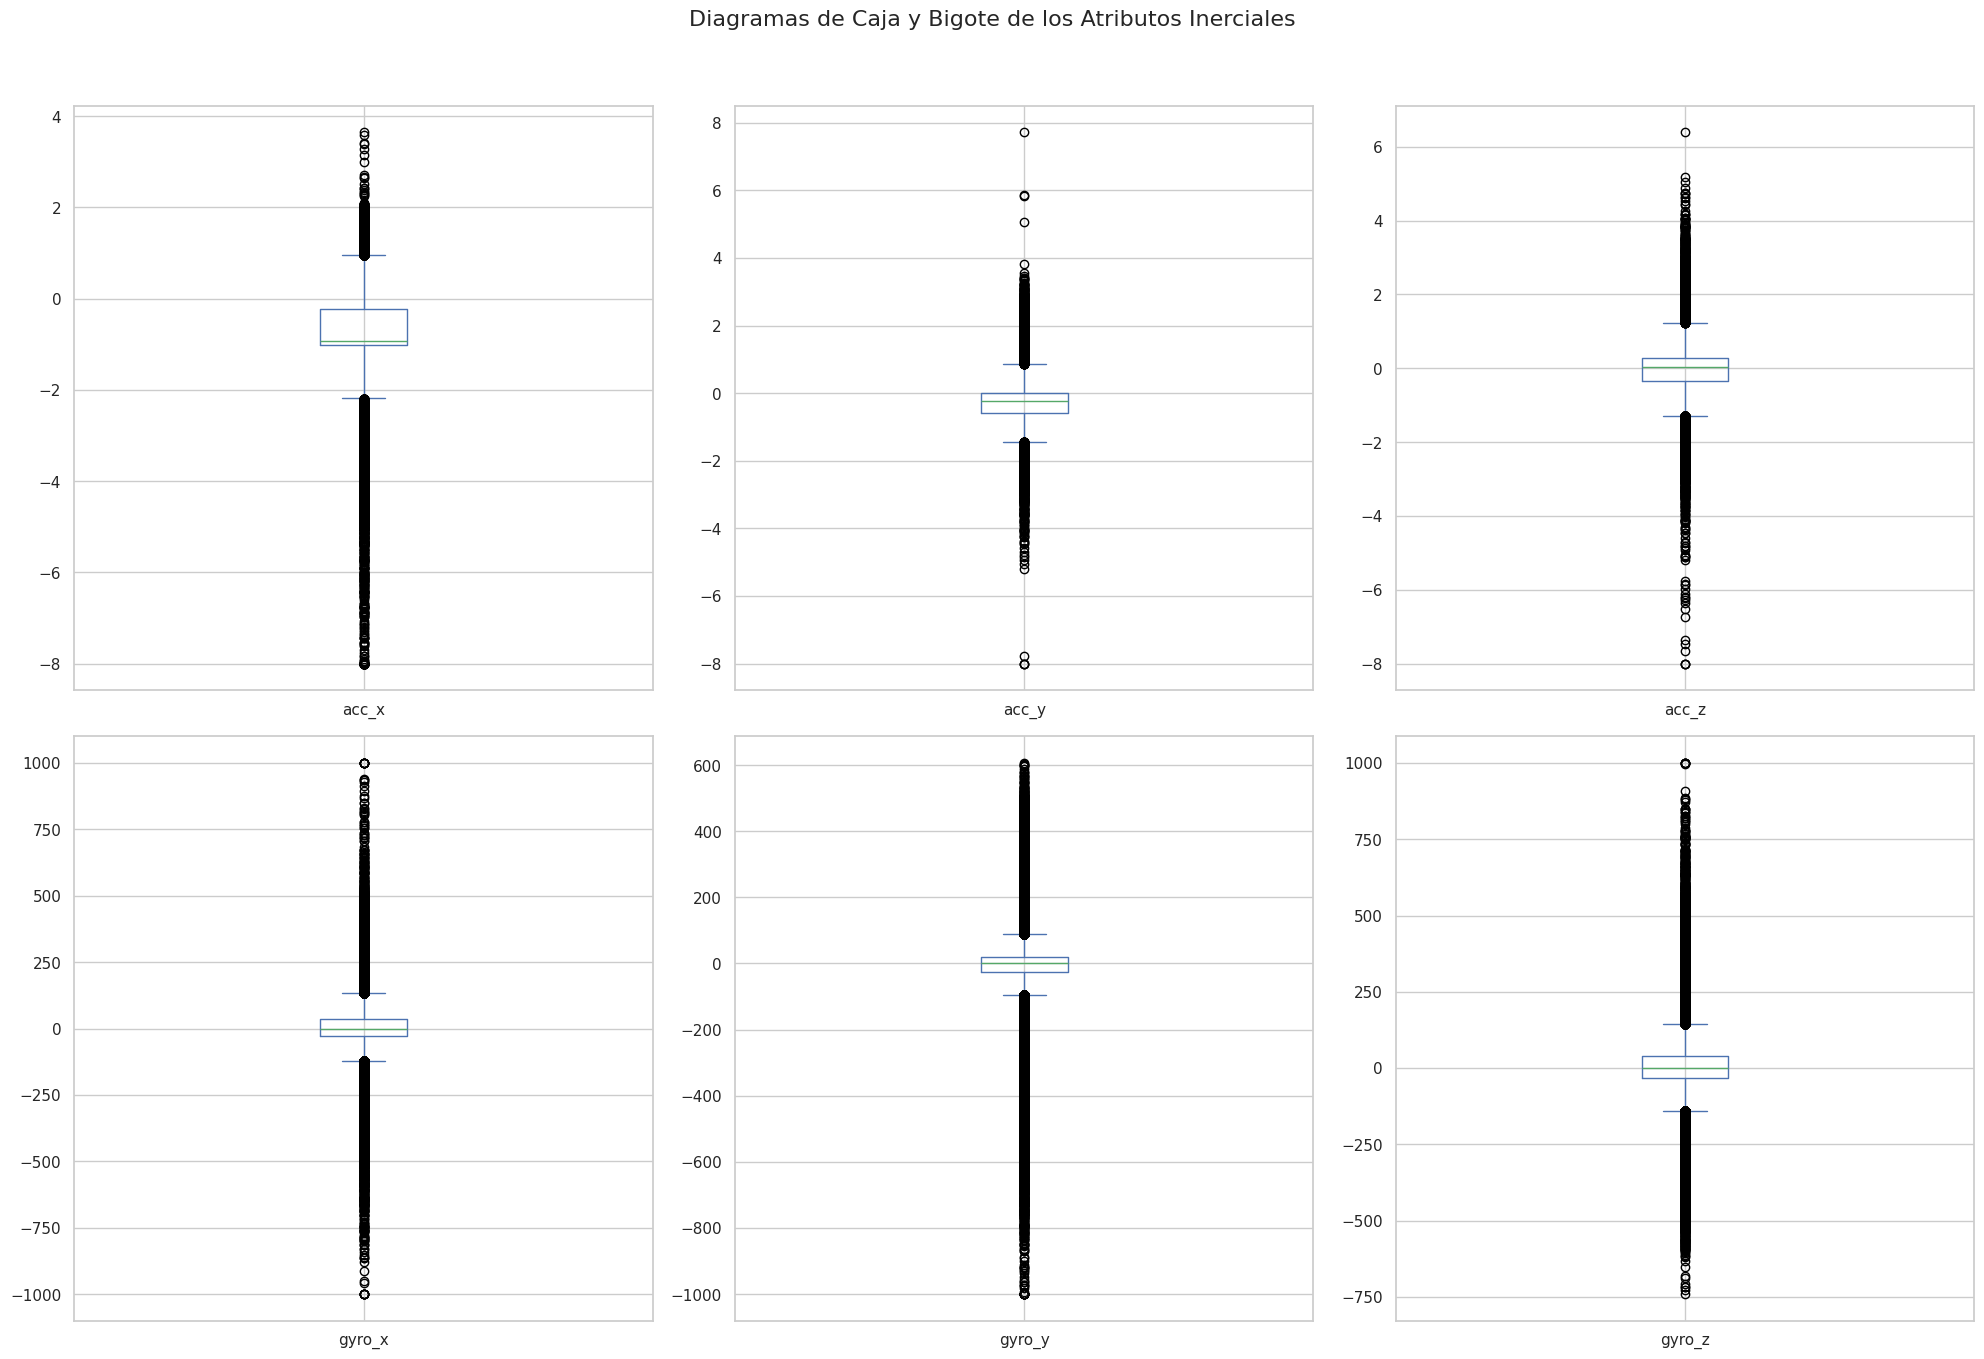

In [ ]:
sns.set(style="whitegrid")

inertial_df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(20, 20), sharex=False)
plt.suptitle("Diagramas de Caja y Bigote de los Atributos Inerciales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Genera la matriz de correlación de los atributos para cada una de las bases de datos.

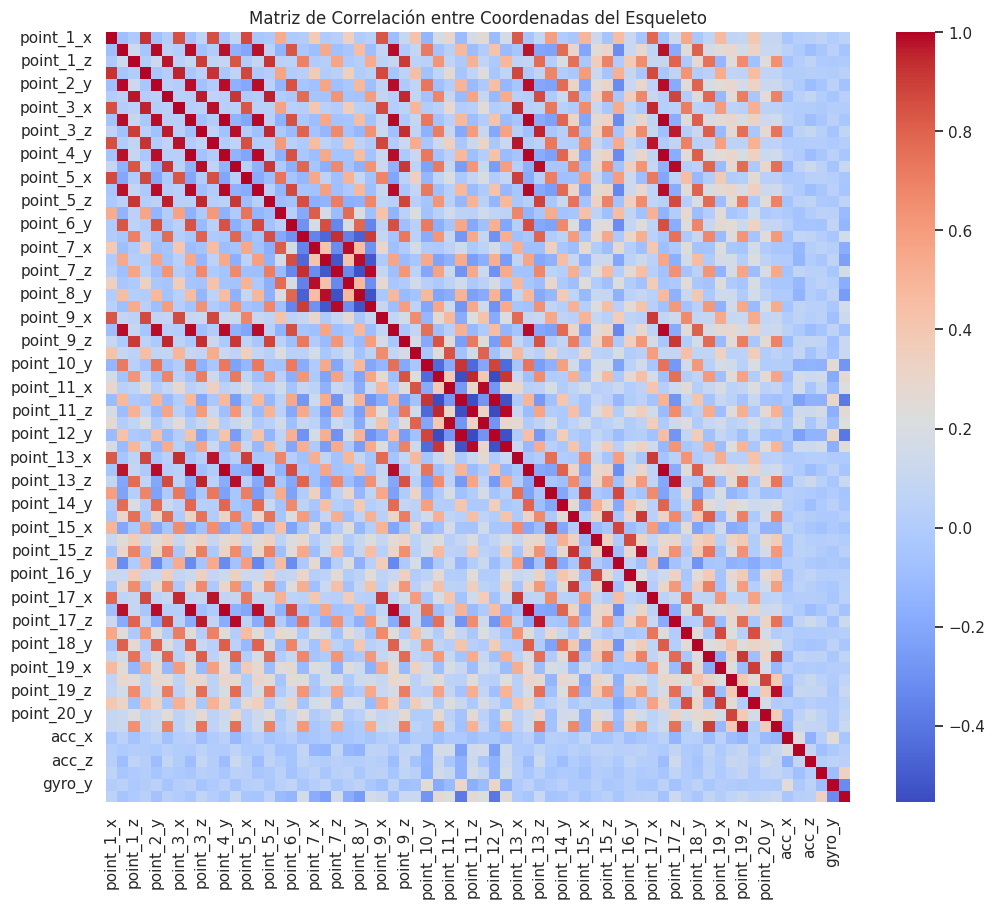

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(final_correlation, cmap="coolwarm", annot=False)
plt.title("Matriz de Correlación entre Coordenadas del Esqueleto")
plt.show()


# Genera la matriz de dispersión de los atributos para cada base de datos

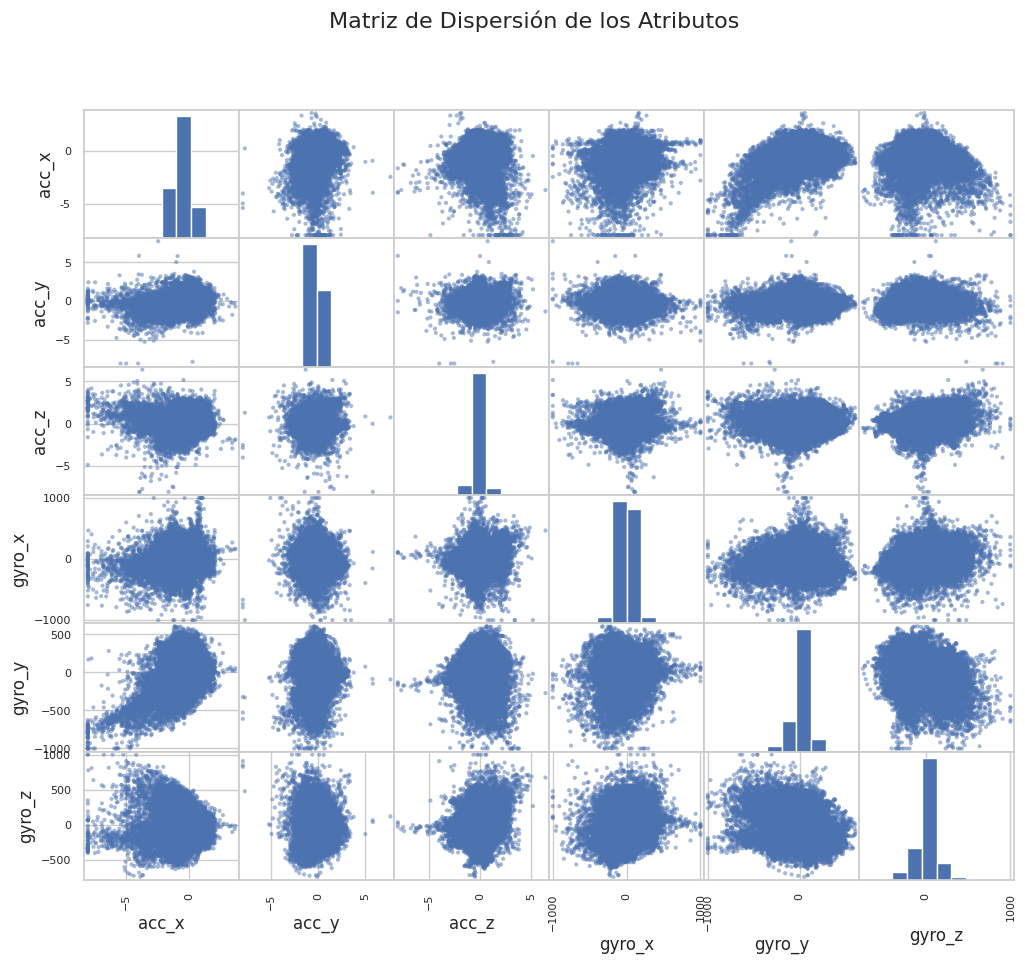

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(inertial_df, figsize=(12, 10), diagonal='hist')

plt.suptitle("Matriz de Dispersión de los Atributos", fontsize=16)
plt.show()

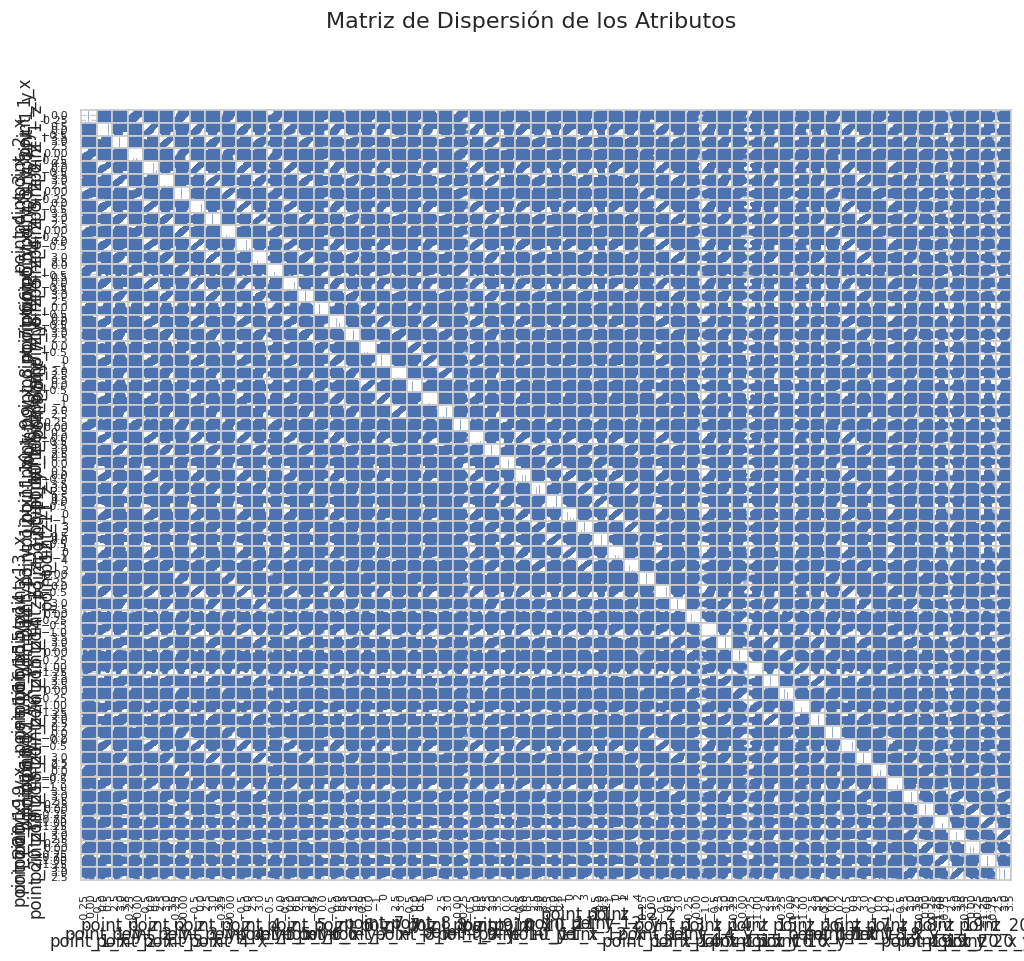

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(skeleton_df, figsize=(12, 10), diagonal='hist')

plt.suptitle("Matriz de Dispersión de los Atributos", fontsize=16)
plt.show()

# Aplica escalamiento, normalización o estandarización

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
skeleton_df[:] = pd.DataFrame(scaler.fit_transform(skeleton_df), columns=skeleton_df.columns, index=skeleton_df.index)
skeleton_df

point_1_x  point_1_y  point_1_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0           0.954107   0.184740  -0.402439   
                            1           0.962711   0.184750  -0.401519   
                            2           0.972738   0.184820  -0.400819   
                            3           0.981852   0.184798  -0.400351   
                            4           0.989620   0.184792  -0.399976   
...                                          ...        ...        ...   
27        6         4       109        -0.479459   1.516892  -0.811564   
                            110        -0.476271   1.518019  -0.818291   
                            111        -0.469461   1.514991  -0.823516   
                            112        -0.462806   1.513550  -0.826279   
                            113        -0.455529   1.512711  -0.827382   

                                       point_2_x  point_2_y  point_2_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0           1.231253   0.195695  -0.180314   
                            1           1.234265   0.195201  -0.180406   
                            2           1.235518   0.194626  -0.181050   
                            3           1.236410   0.194030  -0.181954   
                            4           1.236969   0.193440  -0.183012   
...                                          ...        ...        ...   
27        6         4       109        -0.590104   1.475882  -0.865757   
                            110        -0.588352   1.475562  -0.868590   
                            111        -0.585433   1.475039  -0.870870   
                            112        -0.581865   1.474597  -0.872598   
                            113        -0.577873   1.474220  -0.873748   

                                       point_3_x  point_3_y  point_3_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0           1.370031   0.164318  -0.218646   
                            1           1.373686   0.164190  -0.217405   
                            2           1.376528   0.164124  -0.216503   
                            3           1.378934   0.164089  -0.215821   
                            4           1.380942   0.164087  -0.215313   
...                                          ...        ...        ...   
27        6         4       109        -0.698272   1.438214  -0.931979   
                            110        -0.694500   1.437529  -0.938045   
                            111        -0.688846   1.436926  -0.943167   
                            112        -0.679675   1.436643  -0.947704   
                            113        -0.668717   1.436578  -0.951323   

                                       point_4_x  point_4_y  point_4_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0           1.457693   0.173617  -0.360768   
                            1           1.461745   0.173612  -0.359660   
                            2           1.465418   0.173607  -0.358699   
                            3           1.468698   0.173605  -0.357871   
                            4           1.471632   0.173632  -0.357156   
...                                          ...        ...        ...   
27        6         4       109        -0.747519   1.393781  -0.878818   
                            110        -0.743109   1.393123  -0.885436   
                            111        -0.735972   1.392733  -0.891617   
                            112        -0.722837   1.392984  -0.898110   
                            113        -0.706649   1.393637  -0.904021   

                                       point_5_x  point_5_y  point_5_z  \
action_id person_id test_id frame_idx                                    
1         1         1       0          

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
inertial_df[:] = pd.DataFrame(scaler.fit_transform(inertial_df), columns=inertial_df.columns, index=inertial_df.index)
inertial_df

acc_x     acc_y     acc_z    gyro_x  \
action_id person_id test_id frame_idx                                           
1         1         1       0         -0.400328  0.198696 -0.279955  0.023827   
                            1         -0.403576  0.244694 -0.221485  0.039737   
                            2         -0.420473  0.245614 -0.196797  0.085595   
                            3         -0.376932  0.277813 -0.164748  0.142996   
                            4         -0.398702  0.154076 -0.185103  0.134261   
...                                         ...       ...       ...       ...   
27        6         4       297       -0.380505  0.917197  0.532997 -0.028895   
                            298       -0.352235  0.899259  0.568079 -0.046677   
                            299       -0.337613  0.898799  0.571110 -0.041061   
                            300       -0.351260  0.920417  0.561582 -0.057283   
                            301       -0.384405  0.953076  0.555086 -0.077873   

                                         gyro_y    gyro_z  
action_id person_id test_id frame_idx                      
1         1         1       0          0.056414  0.002594  
                            1          0.060228  0.003341  
                            2          0.071126  0.010309  
                            3          0.085021  0.020265  
                            4          0.078482  0.004336  
...                                         ...       ...  
27        6         4       297        0.016909 -0.049672  
                            298        0.043881 -0.053156  
                            299        0.047151 -0.049174  
                            300        0.036253 -0.035237  
                            301        0.028624 -0.020552  

[155638 rows x 6 columns]

# Time Series

**Skeleton**

* Tamaño de ventana: 90 frames
* Frecuencia de muestreo: ~30 FPS
* Duración por ventana: 3 segundos
* Los datos fueron agrupados por action_id (acción realizada).

In [ ]:
windows = []
window_size = 90 #The frame rate is approximately 30 frames per second.

for action, group in skeleton_df.groupby('action_id'):  # Solo agrupamos por acción
    for i in range(0, len(group) - window_size + 1, window_size):
        window = group.iloc[i:i+window_size]
        windows.append(window)

print(f"Se generaron {len(windows)} ventanas de {window_size} frames cada una.")


Se generaron 635 ventanas de 90 frames cada una.


**inertial**

Tamaño de ventana: 155 aprox frames

numero de ventanas: 38 . Este valor se calculó en función del promedio total de frames correspondientes a las 27 acciones y del número de frames requeridos cumplir los 3 segundos aprox.

Frecuencia de muestreo: 50 hz

Duración por ventana: 3 segundos

Los datos fueron agrupados por action_id (acción realizada).

In [20]:
num_windows = 38
segmented_windows = []

# Agrupar por acción
for action, action_data in inertial_df.groupby("action_id"):
    window_size = len(action_data) // num_windows  # Tamaño aproximado de cada ventana

    # Evitar dividir si hay muy pocos frames
    if window_size == 0:
        continue

    # Crear las ventanas dentro de cada acción
    for i in range(num_windows):
        start = i * window_size
        end = (i + 1) * window_size
        segmented_windows.append(action_data.iloc[start:end])

# Mostrar cuántas ventanas se generaron
print(f"Total de ventanas generadas: {len(segmented_windows)}")



Total de ventanas generadas: 1026


# features

**skeleton**

* Calcula el ángulo entre dos vectores definidos por tres puntos (a, b, c).
* Utiliza la multiplicación de matrices con np.einsum para calcular el producto * punto eficientemente.
* Normaliza los vectores para evitar problemas con divisiones por cero.
* Aplica la función np.arccos para obtener el ángulo en radianes, luego lo * normaliza dividiéndolo entre π.

In [ ]:
def angle_between(a, b, c):
    vec1 = a - b
    vec2 = c - b
    dot_product = np.einsum("ij,ij->i", vec1, vec2)
    norm_product = np.linalg.norm(vec1, axis=1) * np.linalg.norm(vec2, axis=1)
    norm_product[norm_product == 0] = 1e-8  # Evitar división por 0
    angles = np.arccos(np.clip(dot_product / norm_product, -1.0, 1.0)) / np.pi
    return angles


* Calcula la distancia euclidiana entre dos puntos en el espacio tridimensional.
* Utiliza la norma L2 de la diferencia entre p1 y p2 a lo largo del eje 1.

In [ ]:
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2, axis=1)


* Calcula la diferencia entre frames consecutivos de una ventana de datos.
* Usa np.diff para obtener la variación temporal en todas las dimensiones.
* útil para calcular velocidad y aceleración a partir de las coordenadas inerciales.

In [ ]:
def temporal_difference(window):
    return np.diff(window.values, axis=0)  # Diferencia entre frames consecutivos

Selección de puntos clave: Se extraen posiciones de cabeza, caderas, rodillas, tobillos, hombros, codos y muñecas.

Cálculo de ángulos:
* body_inclination: Inclinación del cuerpo respecto a la vertical.
* leg_separation: Ángulo entre ambas piernas.
* left_knee_angle y right_knee_angle: Flexión de rodillas.
* left_arm_angle y right_arm_angle: Ángulo de flexión en codos.

Cálculo de métricas antropométricas:
* body_height: Altura promedio del cuerpo desde la cabeza hasta la cadera.
* leg_length: Longitud promedio de la pierna desde la cadera hasta los tobillos.
* arm_length: Longitud del brazo desde el hombro hasta la muñeca.

Cálculo de velocidad de la cabeza:
* Se obtiene a partir de la diferencia temporal de la posición de la cabeza

In [ ]:
features = []

for window in windows:
    feature_vector = {}


    # Extraer posiciones de los puntos necesarios
    head = window[["point_1_x", "point_1_y", "point_1_z"]].values
    spine = window[["point_3_x", "point_3_y", "point_3_z"]].values
    hip_center = window[["point_4_x", "point_4_y", "point_4_z"]].values
    left_hip = window[["point_13_x", "point_13_y", "point_13_z"]].values
    right_hip = window[["point_17_x", "point_17_y", "point_17_z"]].values
    left_knee = window[["point_14_x", "point_14_y", "point_14_z"]].values
    right_knee = window[["point_18_x", "point_18_y", "point_18_z"]].values
    left_ankle = window[["point_15_x", "point_15_y", "point_15_z"]].values
    right_ankle = window[["point_19_x", "point_19_y", "point_19_z"]].values
    left_shoulder = window[["point_5_x", "point_5_y", "point_5_z"]].values
    right_shoulder = window[["point_9_x", "point_9_y", "point_9_z"]].values
    left_elbow = window[["point_6_x", "point_6_y", "point_6_z"]].values
    right_elbow = window[["point_10_x", "point_10_y", "point_10_z"]].values
    left_wrist = window[["point_7_x", "point_7_y", "point_7_z"]].values
    right_wrist = window[["point_11_x", "point_11_y", "point_11_z"]].values

    # Calcular ángulos
    incl_angle = angle_between(head, spine, hip_center) #inclinacion del cuerpo
    leg_separation_angle = angle_between(left_hip, hip_center, right_hip) #Separación de piernas
    left_knee_angle = angle_between(left_hip, left_knee, left_ankle) #Ángulo de la rodilla izquierda
    right_knee_angle = angle_between(right_hip, right_knee, right_ankle) # #Ángulo de la rodilla derecha
    left_arm_angle = angle_between(left_shoulder, left_elbow, left_wrist) #angulo de brazo izquierdo
    right_arm_angle = angle_between(right_shoulder, right_elbow, right_wrist) #angulo de brazo derecho

    # Guardar características
    feature_vector["body_inclination_mean"] = np.mean(incl_angle)
    feature_vector["body_inclination_range"] = np.max(incl_angle) - np.min(incl_angle)

    feature_vector["leg_separation_mean"] = np.mean(leg_separation_angle)
    feature_vector["leg_separation_range"] = np.max(leg_separation_angle) - np.min(leg_separation_angle)

    feature_vector["left_knee_mean"] = np.mean(left_knee_angle)
    feature_vector["left_knee_range"] = np.max(left_knee_angle) - np.min(left_knee_angle)

    feature_vector["right_knee_mean"] = np.mean(right_knee_angle)
    feature_vector["right_knee_range"] = np.max(right_knee_angle) - np.min(right_knee_angle)

    feature_vector["left_arm_mean"] = np.mean(left_arm_angle)
    feature_vector["left_arm_range"] = np.max(left_arm_angle) - np.min(left_arm_angle)

    feature_vector["right_arm_mean"] = np.mean(right_arm_angle)
    feature_vector["right_arm_range"] = np.max(right_arm_angle) - np.min(right_arm_angle)

    # Calcular métricas antropométricas
    feature_vector["body_height"] = np.mean(euclidean_distance(head, hip_center))
    feature_vector["leg_length"] = np.mean(euclidean_distance(hip_center, (left_ankle + right_ankle) / 2))
    feature_vector["arm_length"] = np.mean(
        euclidean_distance(left_shoulder, left_wrist) + euclidean_distance(right_shoulder, right_wrist)
    )

    # Calcular velocidad de la cabeza
    head_velocity = np.linalg.norm(temporal_difference(window[["point_1_x", "point_1_y", "point_1_z"]]), axis=1)
    feature_vector["head_velocity"] = np.mean(head_velocity)


    # Agregar ID de acción
    #feature_vector["action_id"] = window.index.get_level_values("action_id")[0]

    # Agregar a la lista
    features.append(feature_vector)

# Convertir a DataFrame
features_skeleton_df = pd.DataFrame(features)

# Mostrar las primeras filas
print(features_skeleton_df.head())


   body_inclination_mean  body_inclination_range  leg_separation_mean  \
0               0.320627                0.509919             0.680776   
1               0.328016                0.531436             0.694381   
2               0.426865                0.787189             0.758361   
3               0.667771                0.538216             0.729192   
4               0.548210                0.715963             0.646744   

   leg_separation_range  left_knee_mean  left_knee_range  right_knee_mean  \
0              0.715124        0.630510         0.363157         0.601197   
1              0.561144        0.630969         0.329113         0.581763   
2              0.709652        0.445804         0.682585         0.328525   
3              0.383972        0.337615         0.354190         0.236706   
4              0.636506        0.276935         0.365549         0.281725   

   right_knee_range  left_arm_mean  left_arm_range  right_arm_mean  \
0          0.223960       0.

**inertial**

* Media, desviación estándar y máximo de cada eje: Capturan tendencia central y variabilidad de la señal.
* Correlaciones (corr_xy, corr_xz, corr_yz): Miden la relación entre ejes, útil para entender la sincronización de movimientos.
* Magnitud (acc_magnitude): Norma euclidiana de la aceleración, representando la intensidad del movimiento.
* Área bajo la curva (acc_magnitude_auc): Indica el nivel total de actividad en una ventana.

In [22]:
feature_vectors = []

for ventana in segmented_windows:
    feature_vector = {}
    #feature_vector["action_id"] = ventana["action_id"].iloc[0]  # Guardar la acción de la ventana

    # Calcular estadísticas por eje
    for columna in ["acc_x", "acc_y", "acc_z" , "gyro_x", "gyro_y", "gyro_z"]:
        feature_vector[f"{columna}_mean"] = ventana[columna].mean()
        feature_vector[f"{columna}_std"] = ventana[columna].std()
        feature_vector[f"{columna}_max"] = ventana[columna].max()

    # Calcular correlaciones entre ejes
    feature_vector["corr_xy"] = ventana["acc_x"].corr(ventana["acc_y"])
    feature_vector["corr_xz"] = ventana["acc_x"].corr(ventana["acc_z"])
    feature_vector["corr_yz"] = ventana["acc_y"].corr(ventana["acc_z"])

    feature_vector["corr_gyro_xy"] = ventana["gyro_x"].corr(ventana["gyro_y"])
    feature_vector["corr_gyro_xz"] = ventana["gyro_x"].corr(ventana["gyro_z"])
    feature_vector["corr_gyro_yz"] = ventana["gyro_y"].corr(ventana["gyro_z"])

    # Magnitud de la señal de aceleración (Norma euclidiana)
    acc_magnitude = np.sqrt(ventana["acc_x"]**2 + ventana["acc_y"]**2 + ventana["acc_z"]**2)
    gyro_magnitude = np.sqrt(ventana["gyro_x"]**2 + ventana["gyro_y"]**2 + ventana["gyro_z"]**2)

    # Características basadas en la magnitud
    feature_vector["acc_magnitude_mean"] = acc_magnitude.mean()
    feature_vector["acc_magnitude_std"] = acc_magnitude.std()
    feature_vector["acc_magnitude_auc"] = np.trapz(acc_magnitude)
    feature_vector["acc_magnitude_diff_mean"] = np.mean(np.diff(acc_magnitude))  # Diferencias medias

    feature_vector["gyro_magnitude_mean"] = gyro_magnitude.mean()
    feature_vector["gyro_magnitude_std"] = gyro_magnitude.std()
    feature_vector["gyro_magnitude_auc"] = np.trapz(gyro_magnitude)
    feature_vector["gyro_magnitude_diff_mean"] = np.mean(np.diff(gyro_magnitude))

    # Agregar el vector de características a la lista
    feature_vectors.append(feature_vector)

# Convertir la lista a un DataFrame
features_inertial_df = pd.DataFrame(feature_vectors)

# Mostrar las primeras filas
print(features_inertial_df.head())


   acc_x_mean  acc_x_std  acc_x_max  acc_y_mean  acc_y_std  acc_y_max  \
0    0.240646   0.593935   1.164286    0.366673   0.943965   2.180327   
1    0.226339   0.560958   1.140890    0.357667   1.063252   2.643537   
2    0.170015   0.608019   1.115870    0.335693   1.060208   2.571778   
3    0.021424   0.484683   1.037558    0.127567   0.871119   2.509220   
4    0.021611   0.619775   1.098647    0.147687   0.944432   2.071310   

   acc_z_mean  acc_z_std  acc_z_max  gyro_x_mean  gyro_x_std  gyro_x_max  \
0   -1.027475   0.482527  -0.072062     0.344773    0.629159    1.624501   
1   -0.902181   0.416027  -0.193766     0.164956    0.739421    2.345444   
2   -0.812064   0.377273  -0.244006     0.162828    0.755343    2.862988   
3   -0.930509   0.519007  -0.113640     0.275342    0.676220    1.937711   
4   -0.602191   0.497863   0.291754     0.348378    0.682104    1.751782   

   gyro_y_mean  gyro_y_std  gyro_y_max  gyro_z_mean  gyro_z_std  gyro_z_max  \
0     0.027734    0.91976

# Estadisticos Descriptivos

**skeleton**

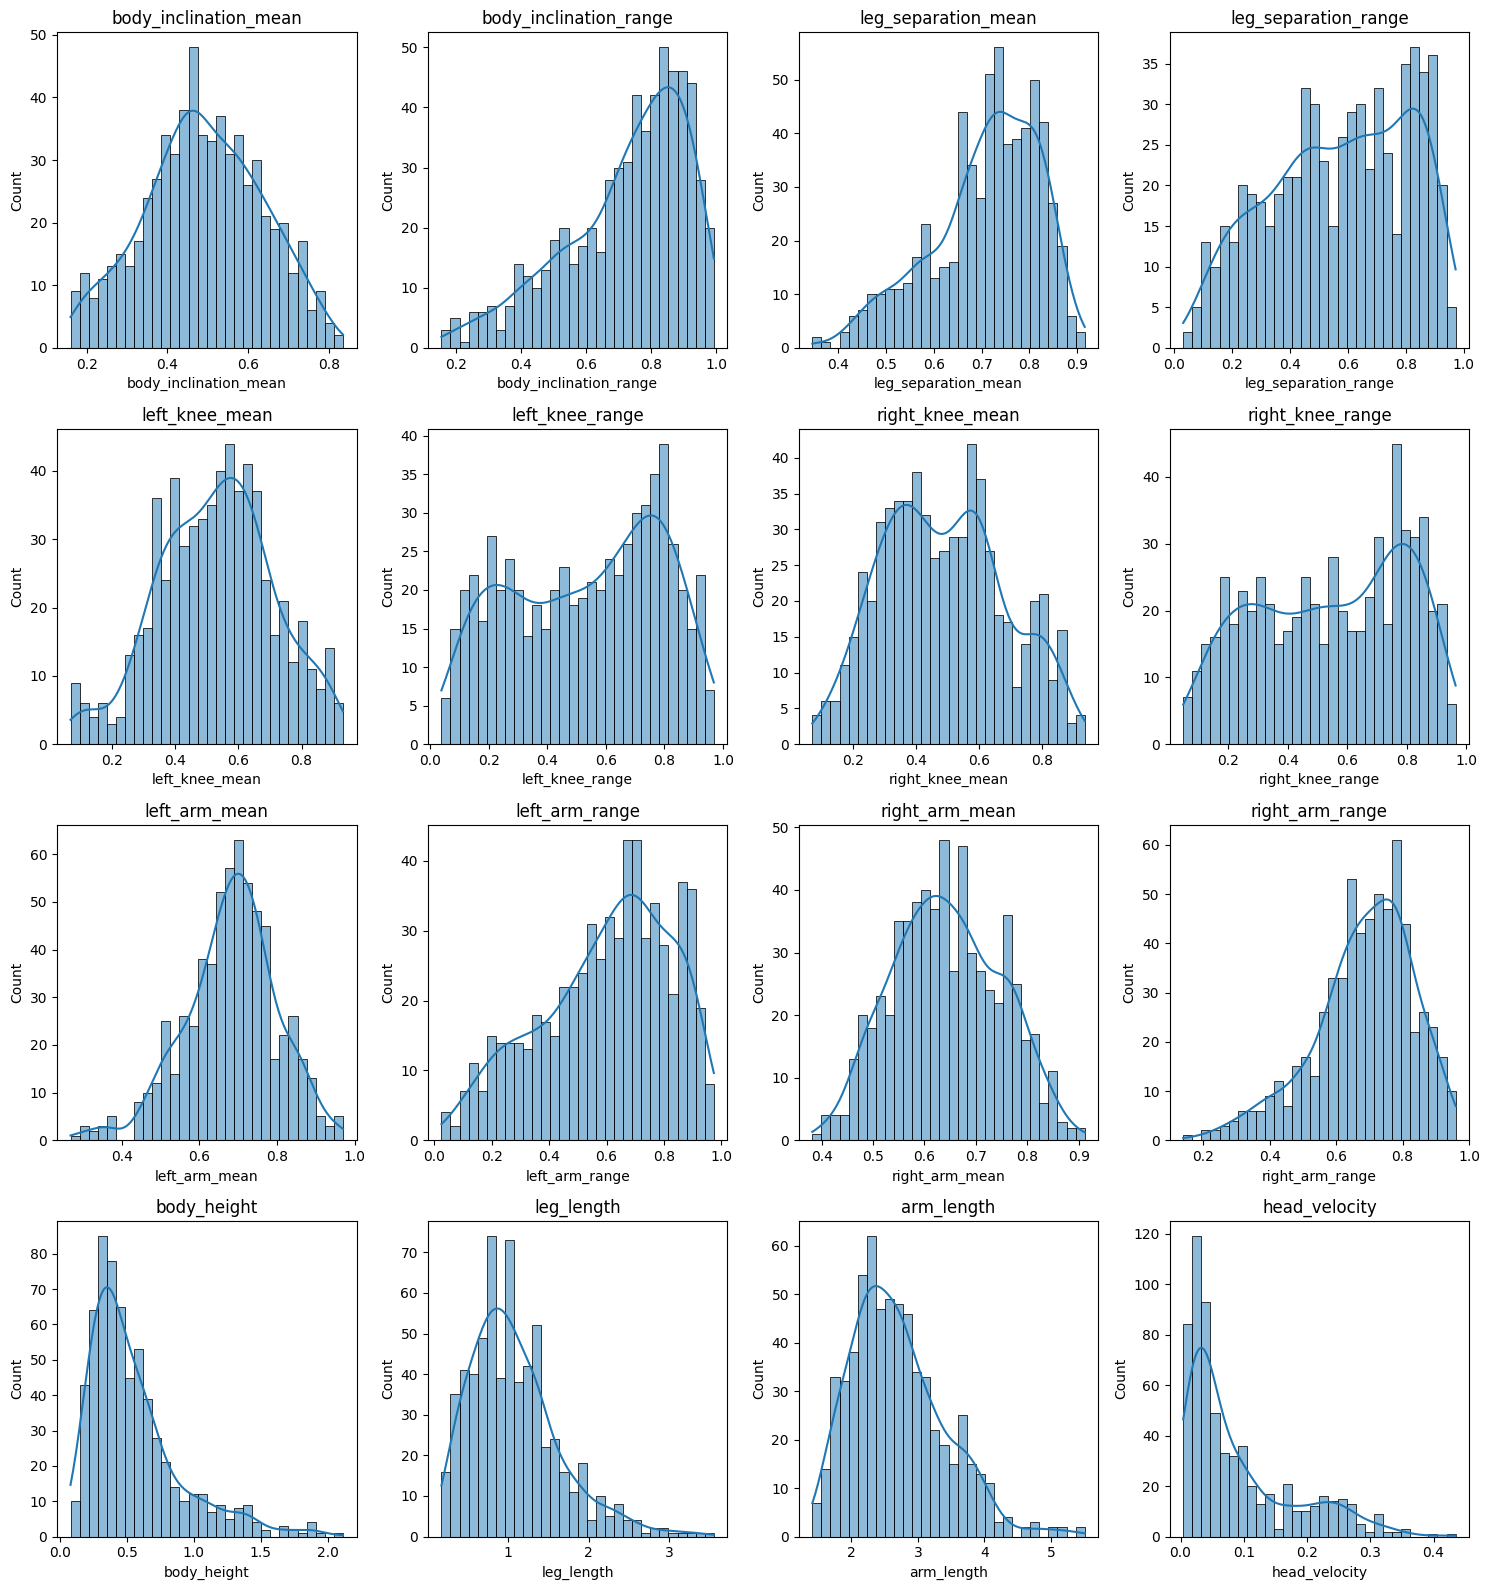

In [ ]:
cols = 4
filas = int(np.ceil(len(features_skeleton_df.columns) / cols))  # Ajuste automático de filas
plt.figure(figsize=(15, 4 * filas))

for i, columna in enumerate(features_skeleton_df.columns):
    plt.subplot(filas, cols, i + 1)
    sns.histplot(features_skeleton_df[columna], bins=30, kde=True)
    plt.title(columna)

plt.tight_layout()
plt.show()


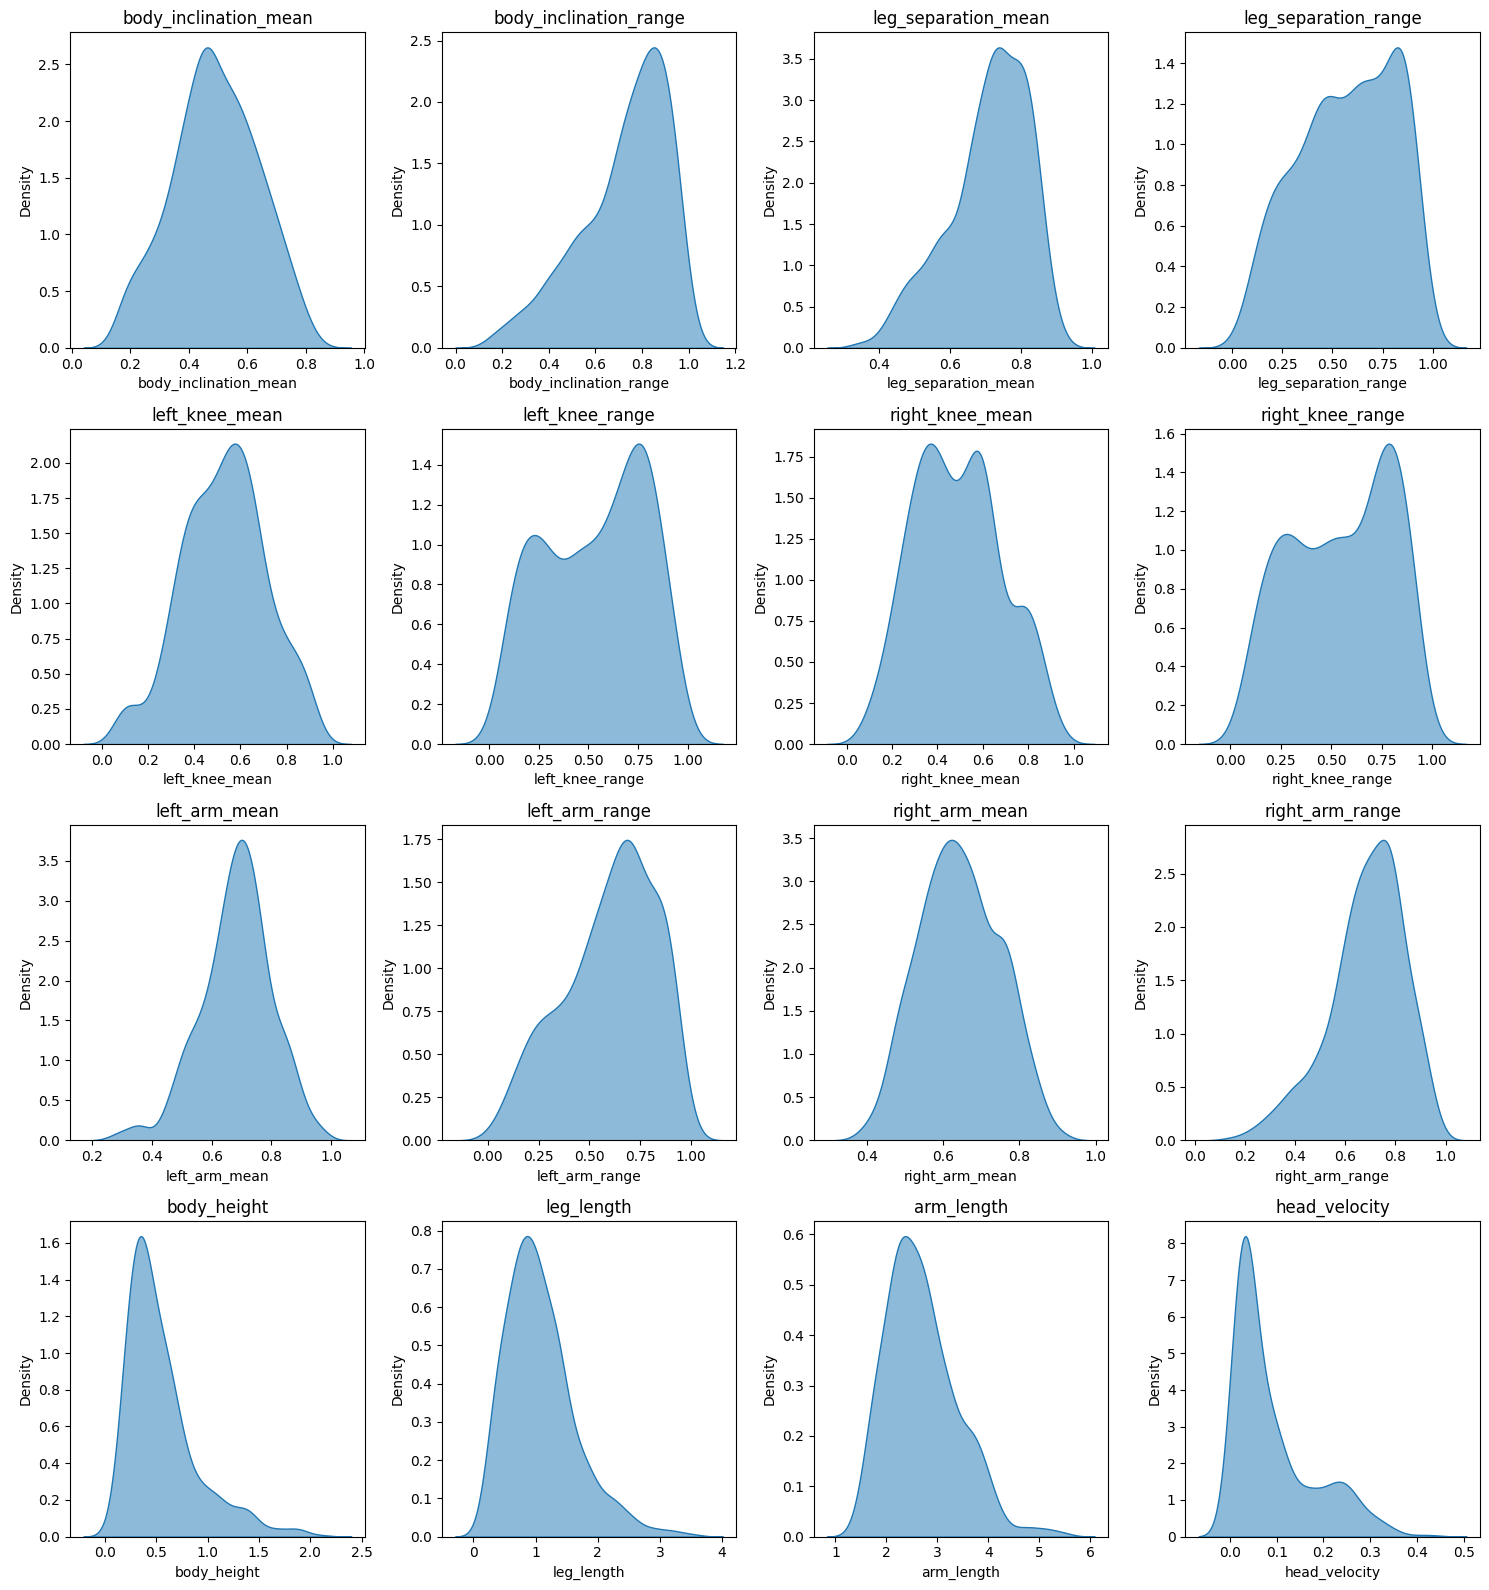

In [ ]:
cols = 4
filas = int(np.ceil(len(features_skeleton_df.columns) / cols))  # Ajuste automático de filas

# Configurar tamaño de la figura
plt.figure(figsize=(15, 4 * filas))

# Crear diagramas de densidad para cada feature
for i, columna in enumerate(features_skeleton_df.columns):
    plt.subplot(filas, cols, i + 1)
    sns.kdeplot(features_skeleton_df[columna], fill=True, alpha=0.5)
    plt.title(columna)

plt.tight_layout()
plt.show()


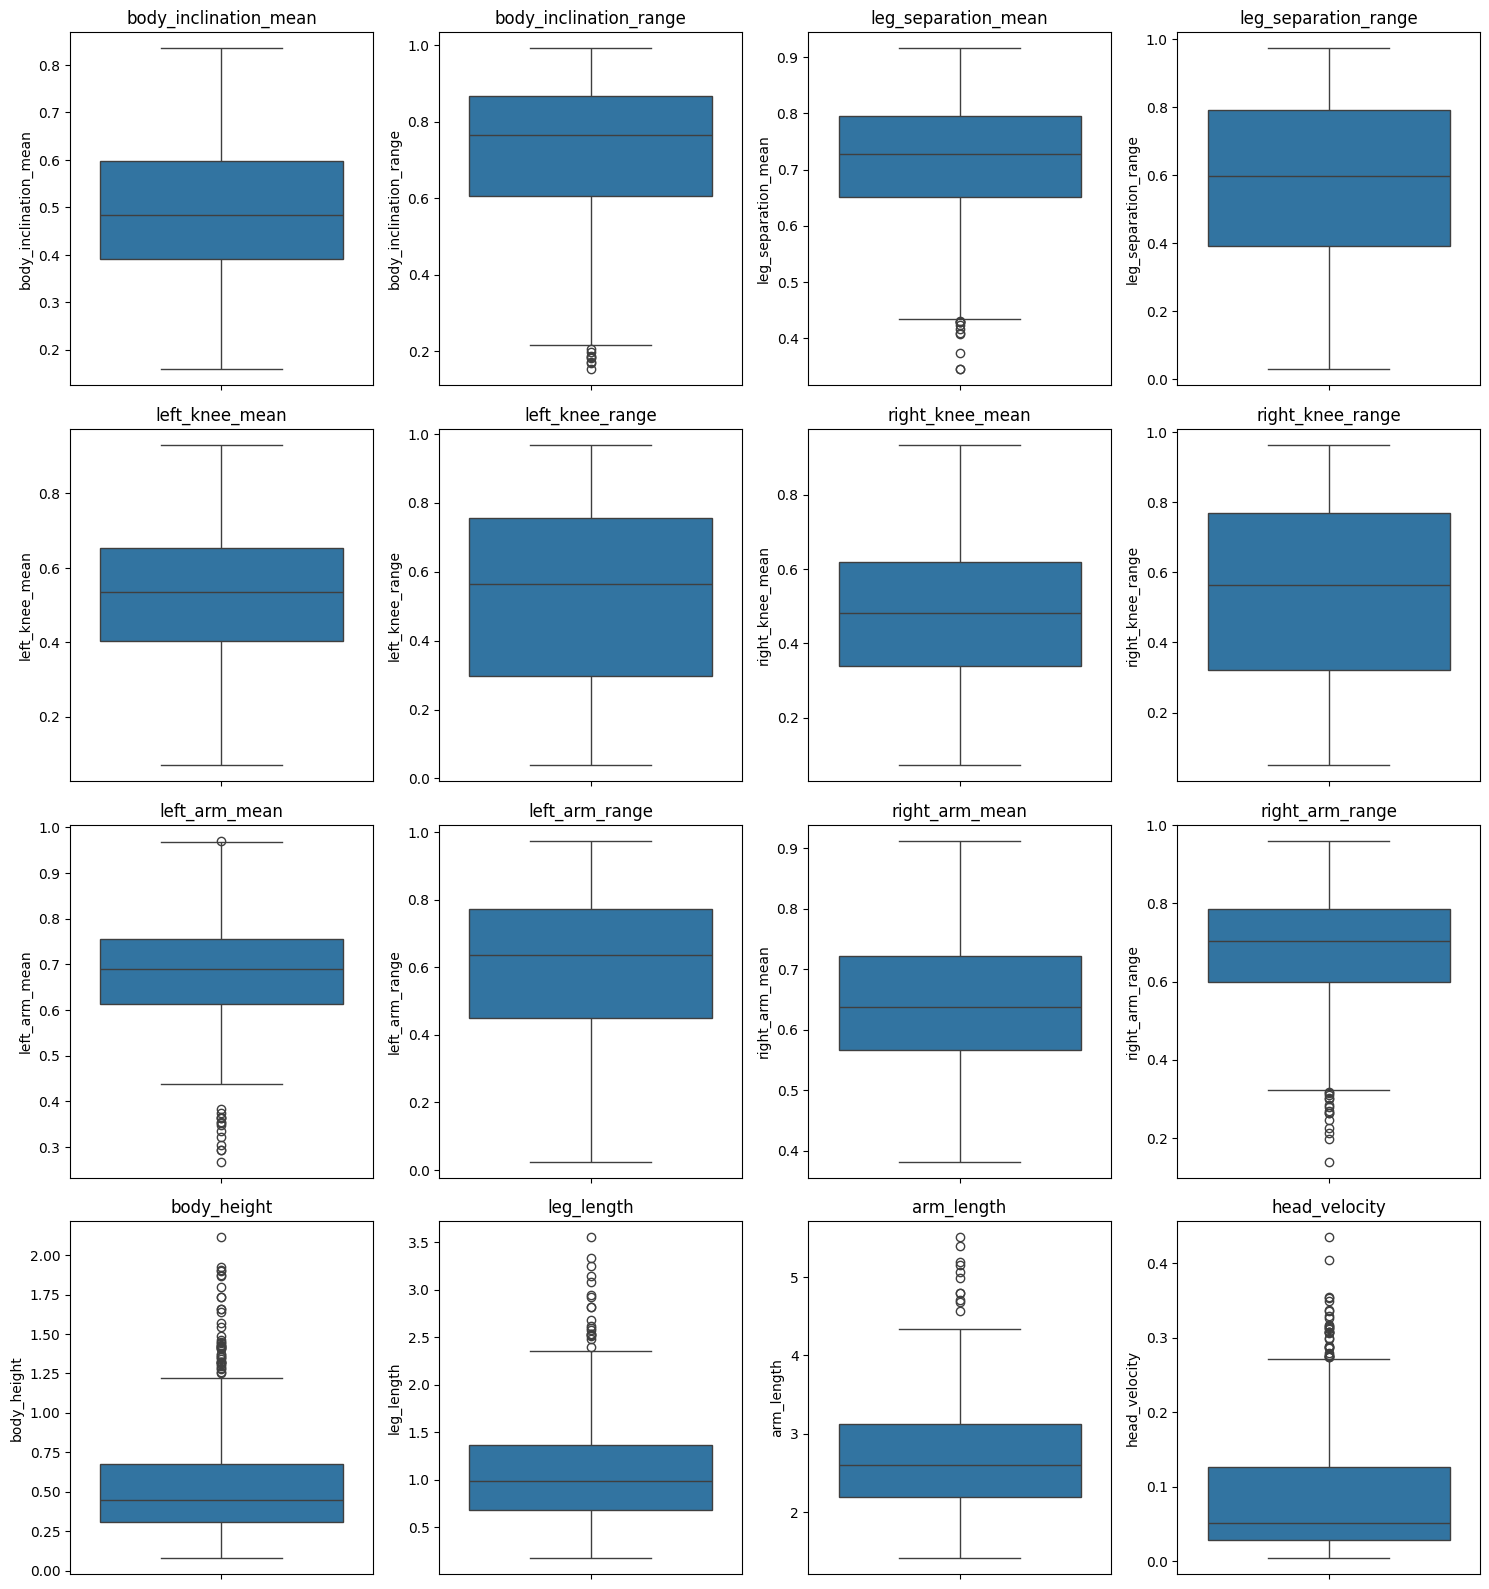

In [ ]:
cols = 4
filas = int(np.ceil(len(features_skeleton_df.columns) / cols))  # Ajuste automático de filas
plt.figure(figsize=(15, 4 * filas))

# Crear boxplots para cada feature
for i, columna in enumerate(features_skeleton_df.columns):
    plt.subplot(filas, cols, i + 1)
    sns.boxplot(y=features_skeleton_df[columna])
    plt.title(columna)

plt.tight_layout()
plt.show()


**Inertial**

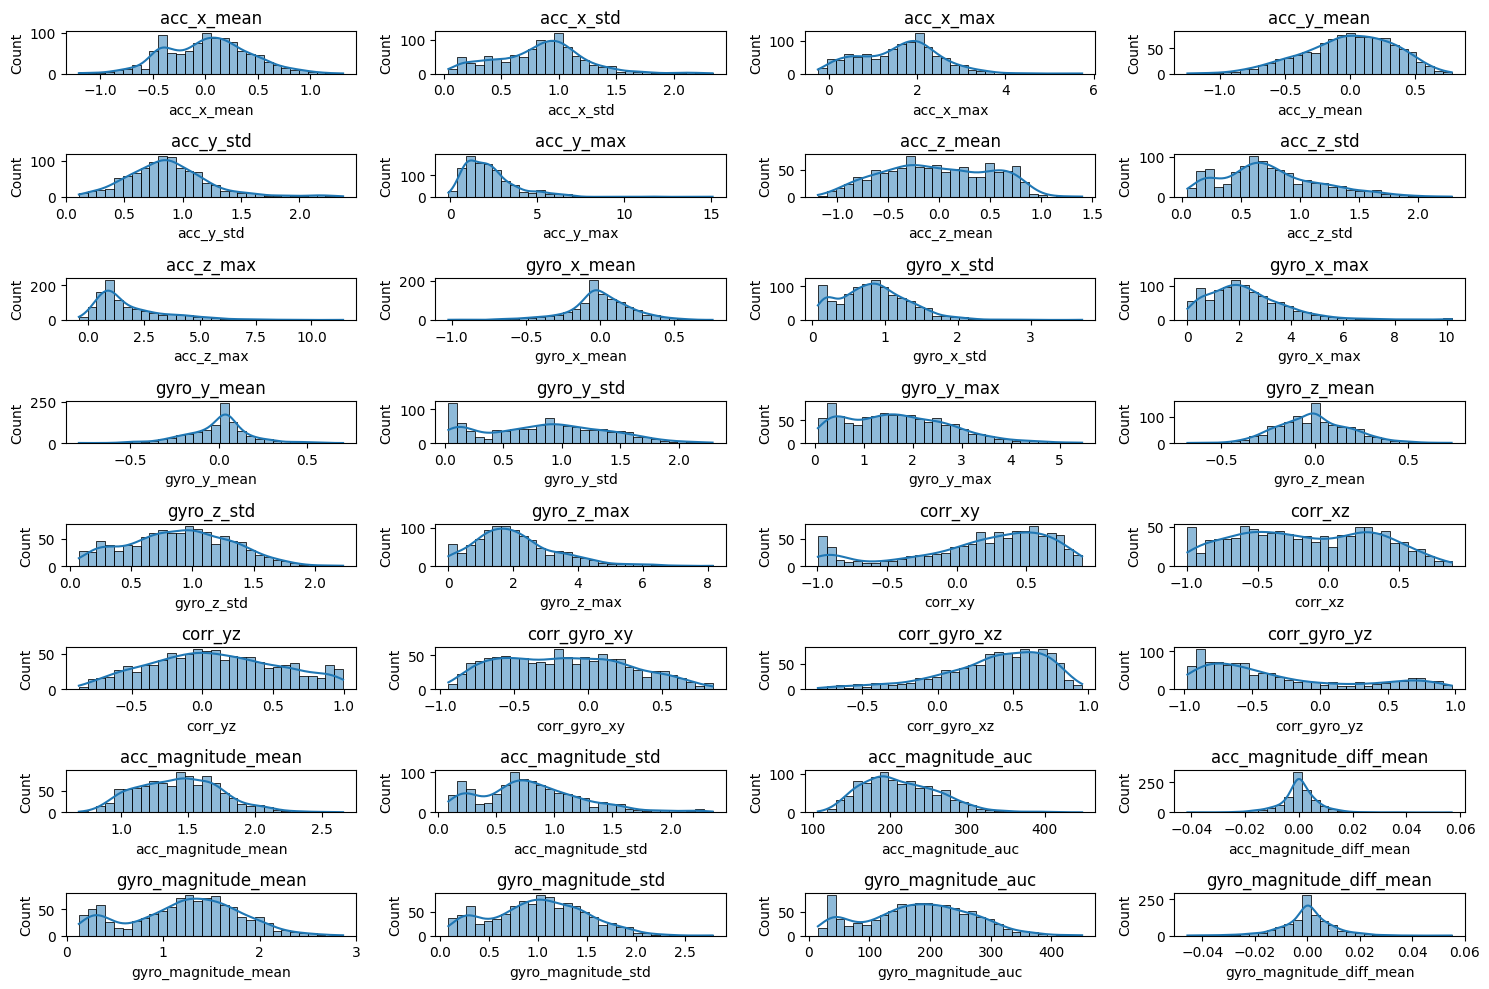

In [26]:
plt.figure(figsize=(15, 10))

for i, columna in enumerate(features_inertial_df):
    plt.subplot(8, 4, i + 1)
    sns.histplot(features_inertial_df[columna], bins=30, kde=True)
    plt.title(columna)

plt.tight_layout()
plt.show()


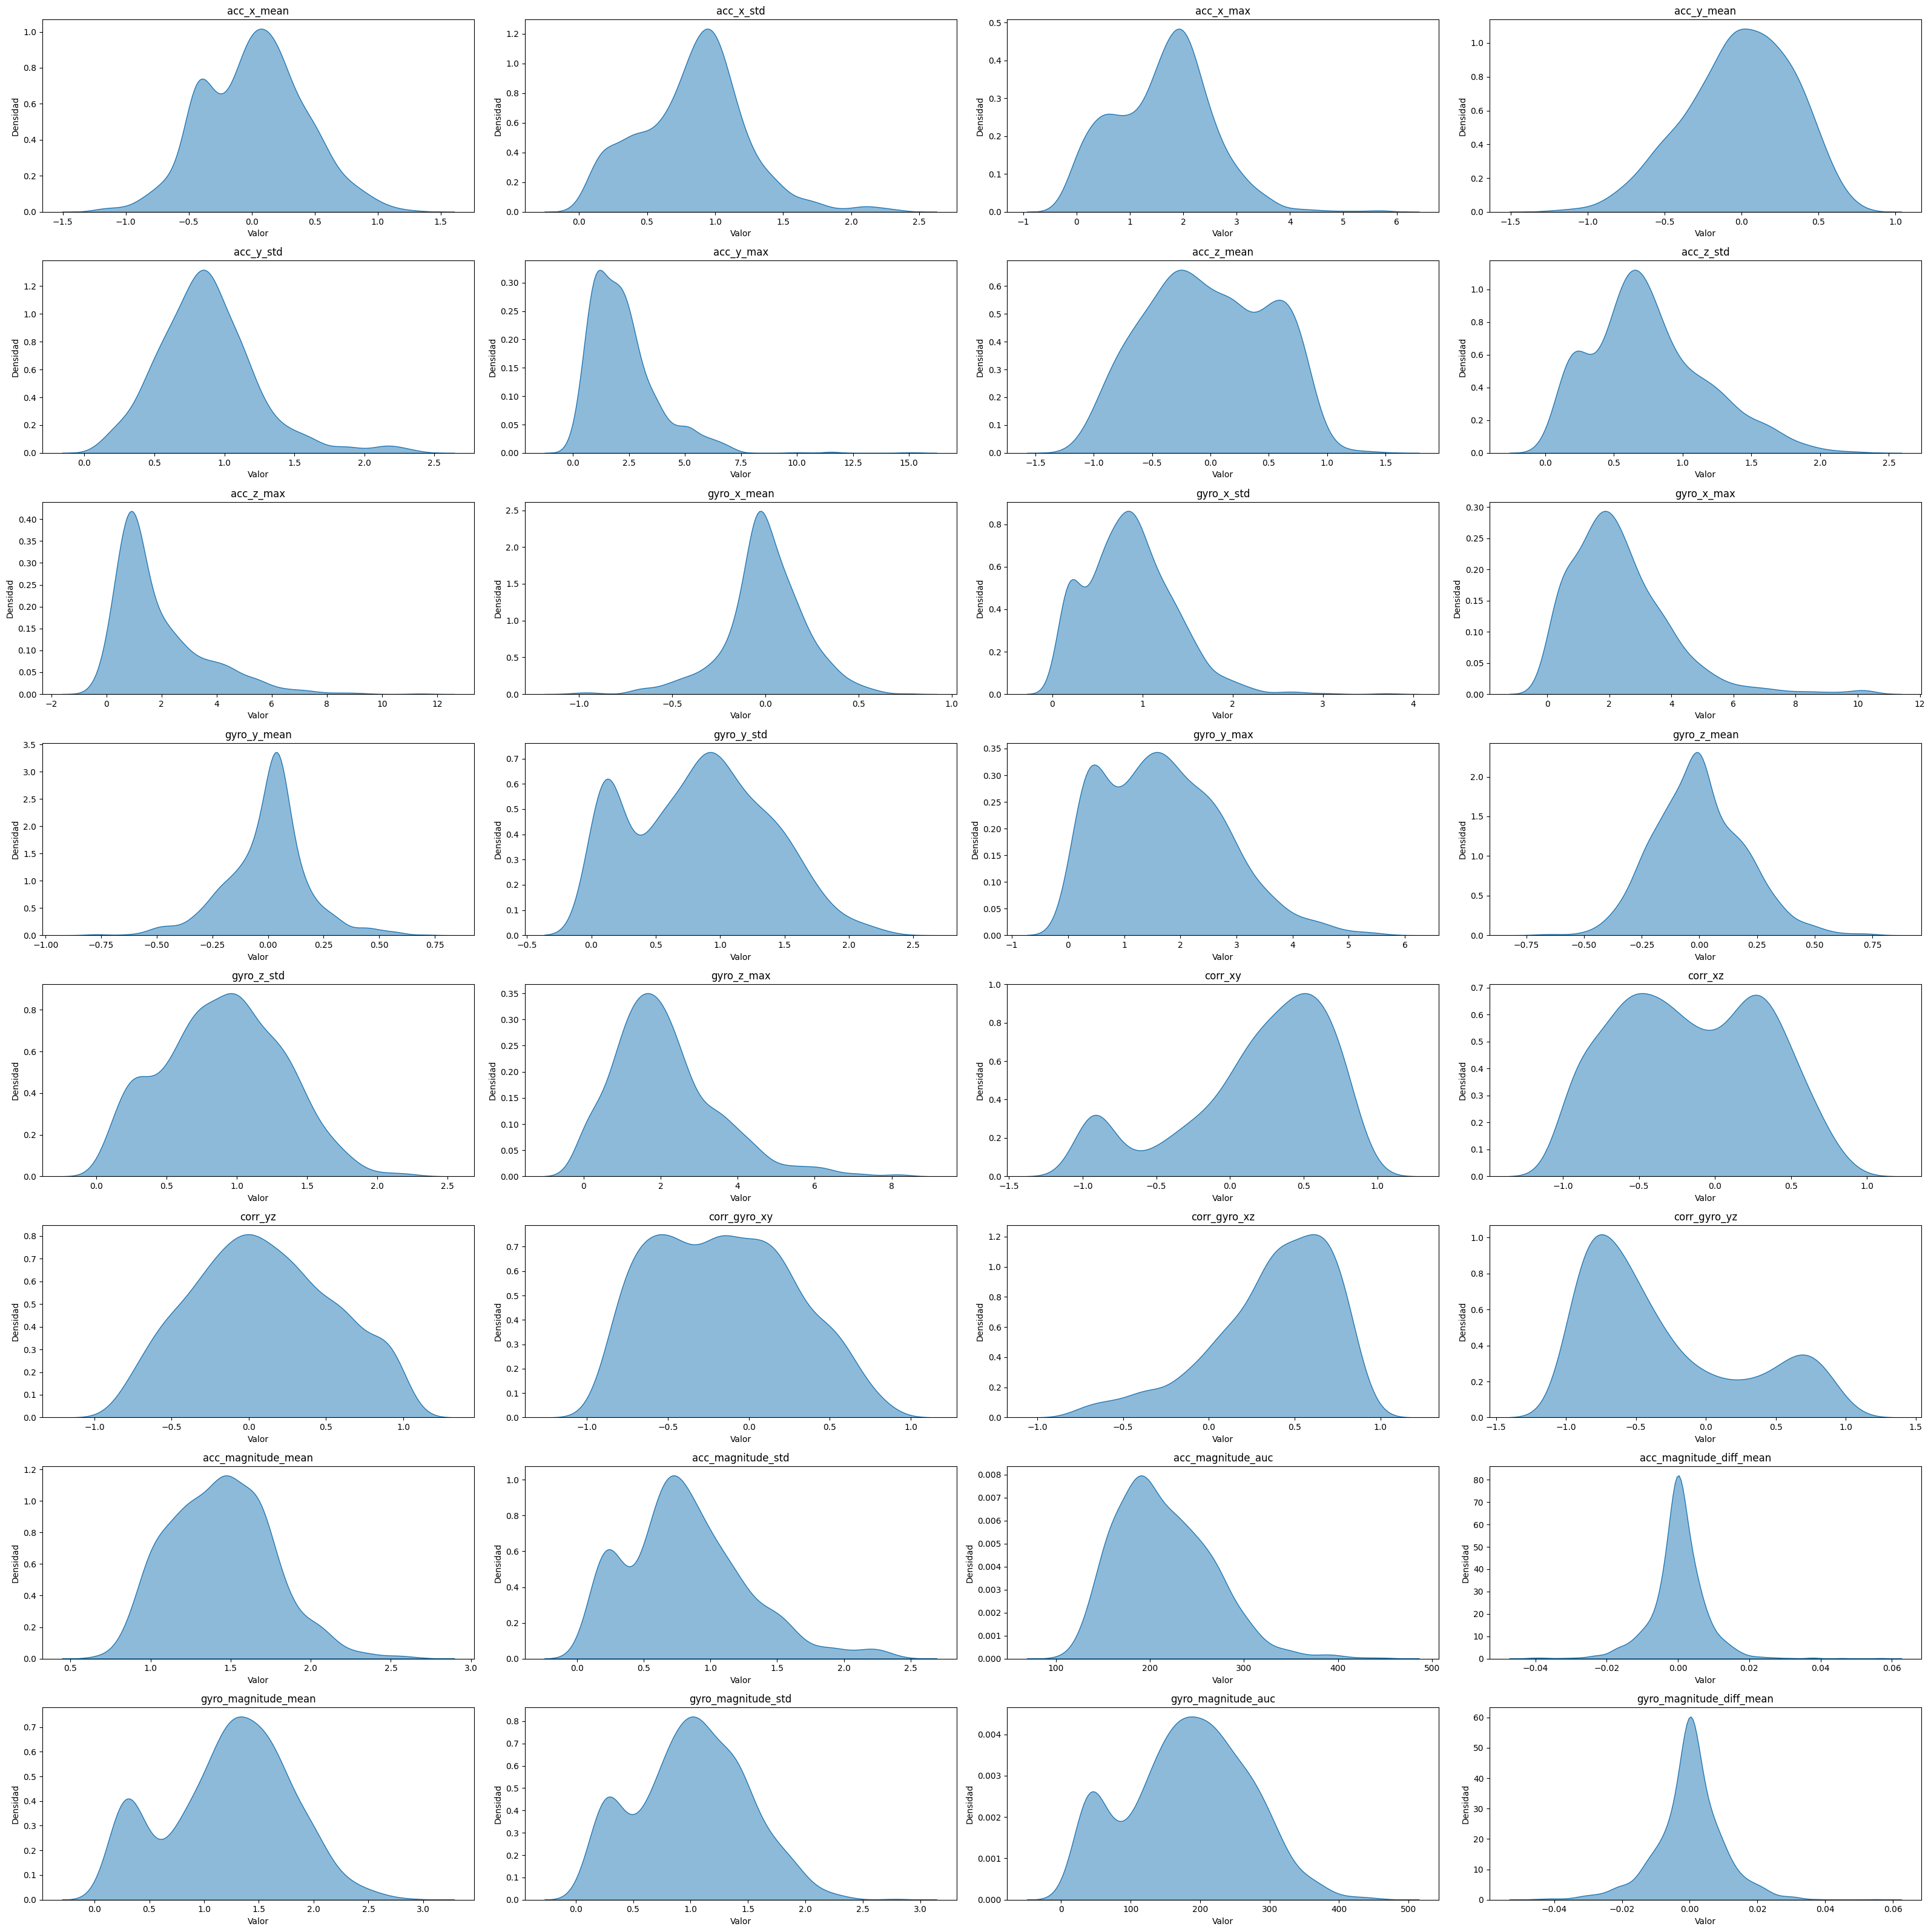

In [27]:
num_features = len(features_inertial_df.columns)
cols = 4
rows = int(np.ceil(num_features / cols))
fig, axes = plt.subplots(rows, cols, figsize=(32, 4 * rows))
axes = axes.flatten()

for i, columna in enumerate(features_inertial_df.columns):
    sns.kdeplot(features_inertial_df[columna], fill=True, ax=axes[i], alpha=0.5)
    axes[i].set_title(columna)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Densidad")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

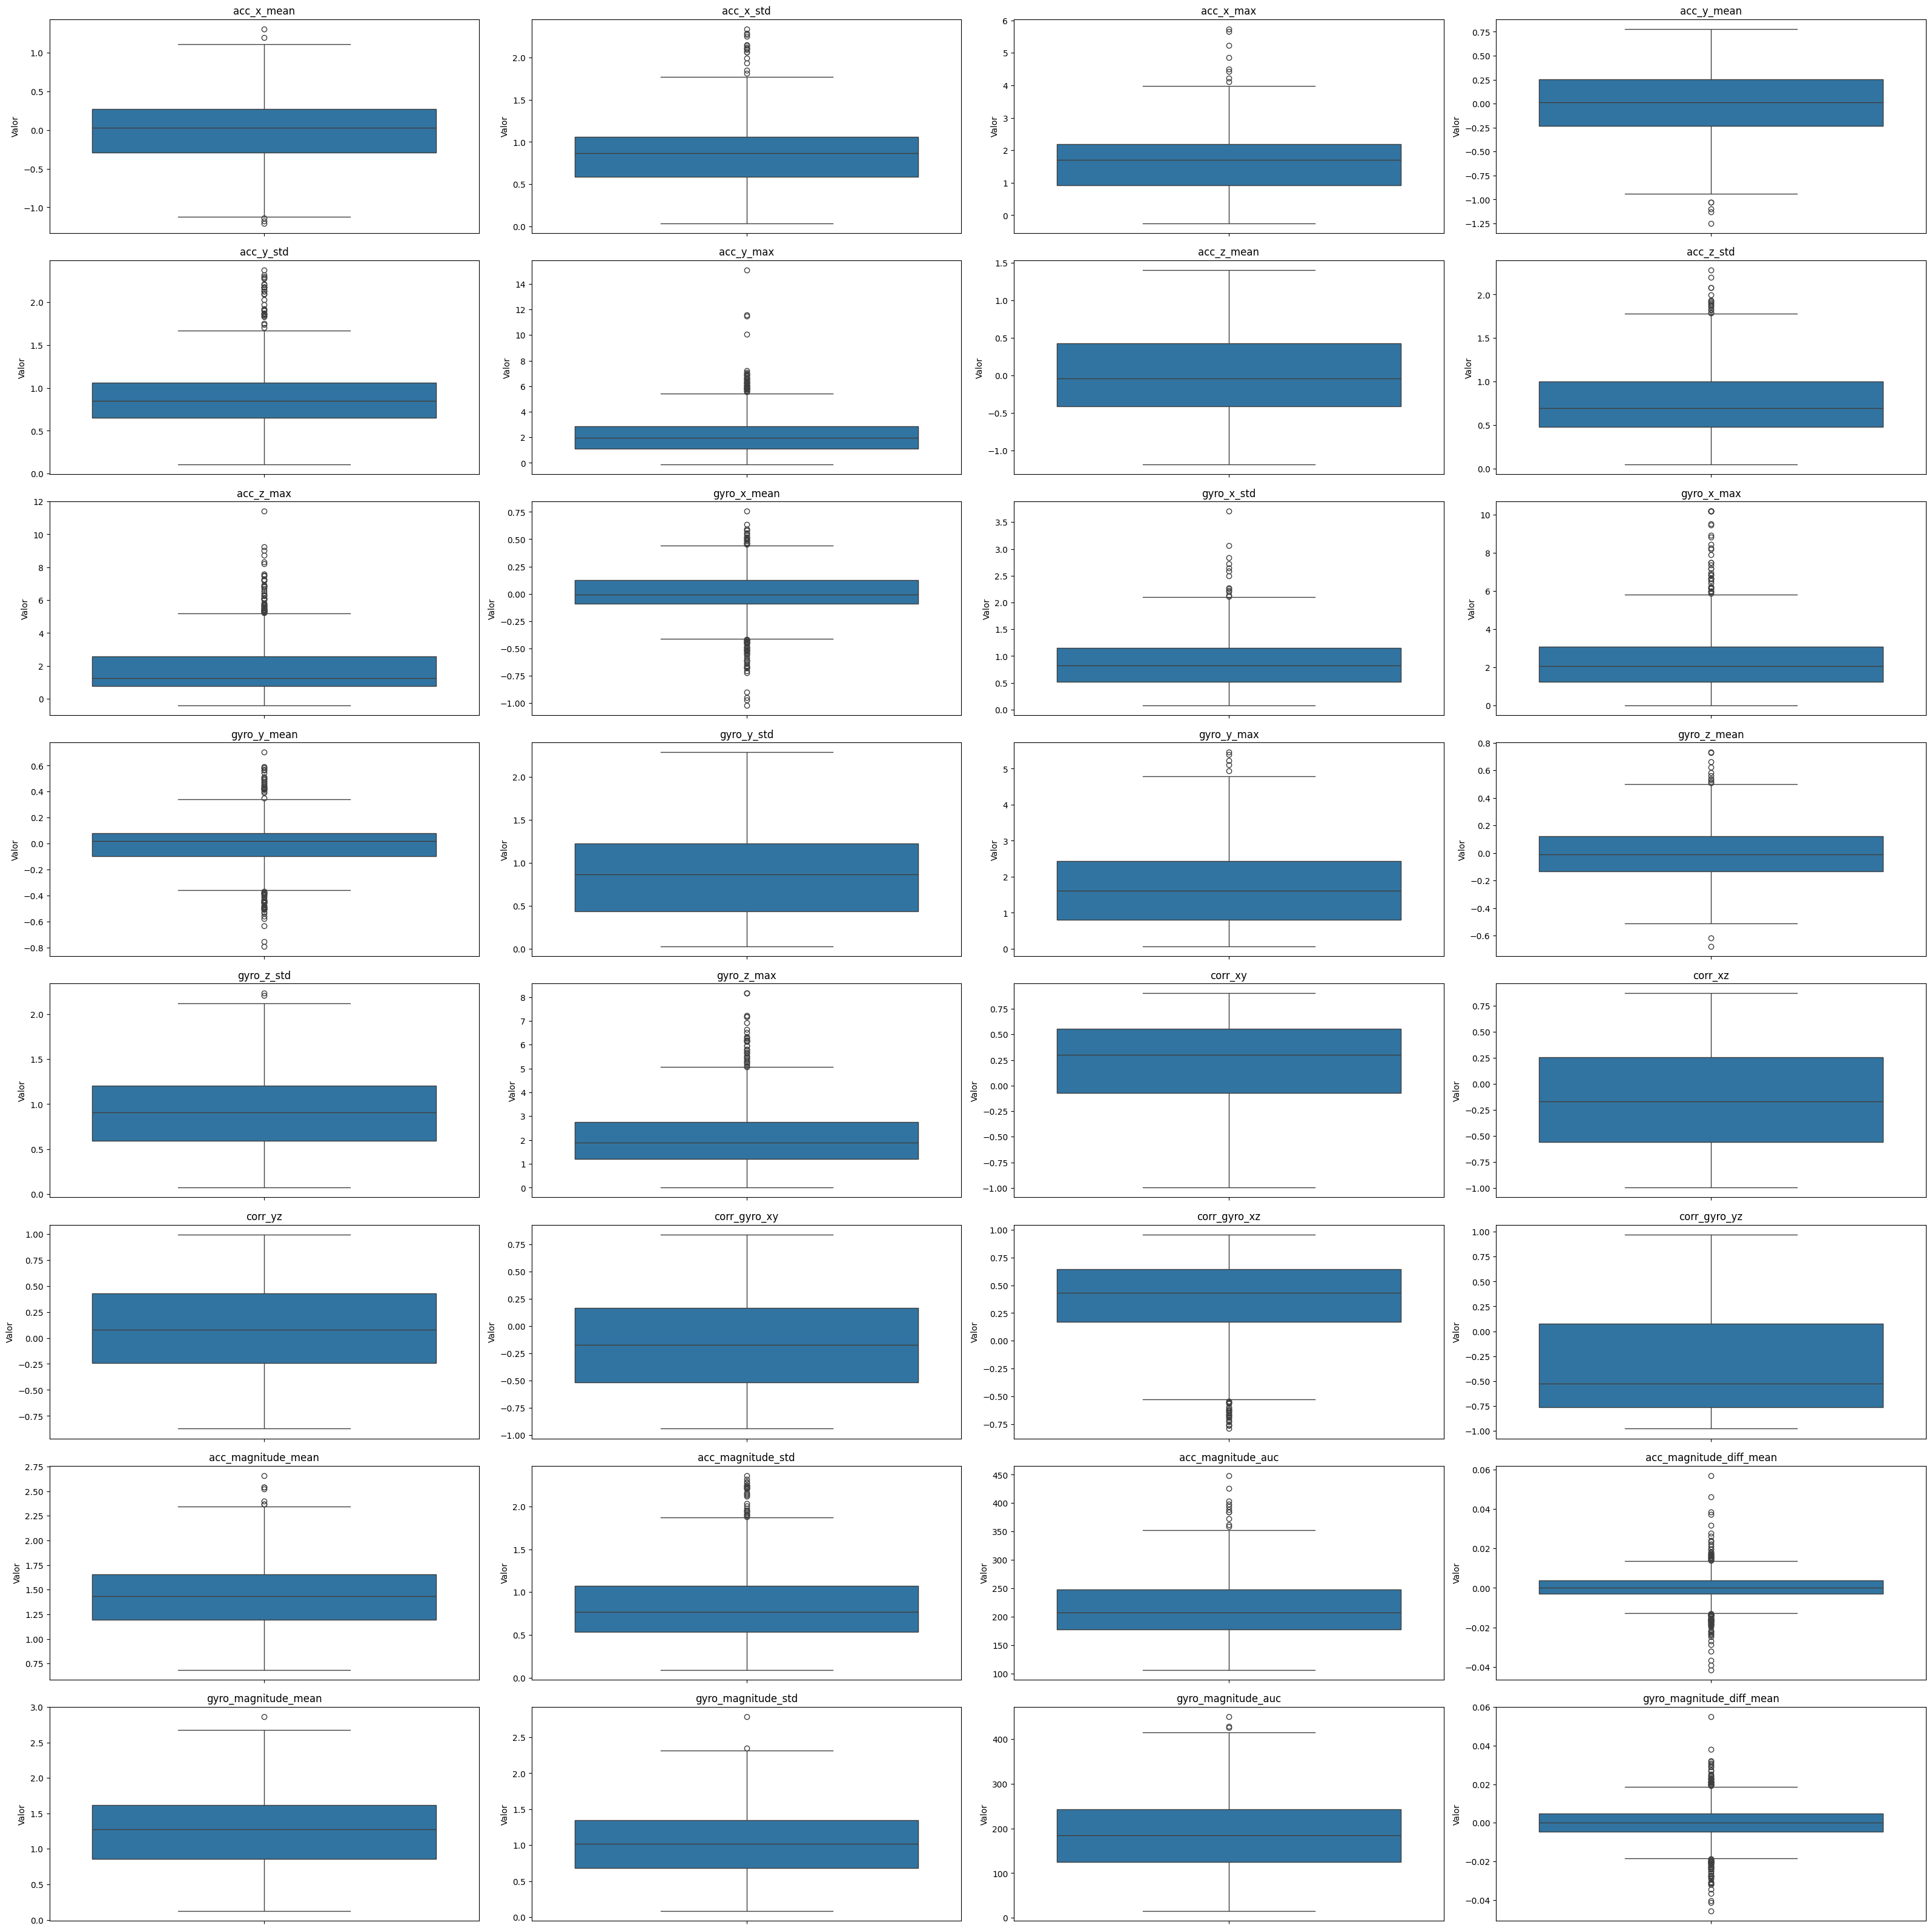

In [28]:
# Definir el tamaño de la figura y la cantidad de subgráficos
num_features = len(features_inertial_df.columns)
cols = 4  # Número de columnas en la cuadrícula
rows = int(np.ceil(num_features / cols))  # Número de filas según la cantidad de features

fig, axes = plt.subplots(rows, cols, figsize=(32, 4 * rows))

# Aplanar los ejes para facilitar el acceso
axes = axes.flatten()

# Crear un boxplot para cada característica
for i, columna in enumerate(features_inertial_df.columns):
    sns.boxplot(y=features_inertial_df[columna], ax=axes[i])
    axes[i].set_title(columna)
    axes[i].set_ylabel("Valor")

# Ocultar los ejes vacíos si el número de características no es múltiplo del número de columnas
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
